# Phase 1 — Validation Suite: State Continued Claims

**Scope:** validate the state continued-claims dataset (`{ABBR}CCLAIMS`, weekly NSA, 51 states, FRED/ALFRED) before any modeling. Initial claims are used only where a check requires them.

**Downstream uses and what they stress:**

| Use case | Failure modes probed here |
|---|---|
| Forecasting | seasonality/stationarity, outliers, breaks, panel completeness (V2, V5, V7) |
| Lead-lag | timestamp & alignment conventions, frequency mixing, sign orientation (V3, V8) |
| Backtesting | point-in-time integrity, release calendar, publication-lag stability, revisions, look-ahead guards (V3, V4, V9) |

**How to read this notebook:** every check registers a row in the final report — `PASS` (criterion met), `WARN` (usable with documented caveat), `FAIL` (blocker). The last two cells render the report and the go/no-go gating decisions. This is a validation suite, not exploratory analysis: each check states its criterion up front.

## Maintained hypotheses — DOL publication mechanics

The dataset is validated against the official mechanics of the series. Each hypothesis lists the checks that test it against the data.

**H1 — Publication schedule.** Continued claims are released every **Thursday at 8:30 AM ET** in the DOL's *Unemployment Insurance Weekly Claims* report, jointly with initial claims (moved to Wednesday when Thursday is a federal holiday).
→ tested by **V3.2** (national vintage weekdays: 96.7% Thu, 3.3% holiday-Wed), **V3.3** (first release lands the expected number of days after the reference week), and illustrated in the **V3.0** worked example.

**H2 — Reference period.** The reference week ends on the **Saturday two weeks prior to the release date**. Continued claims lag initial claims by one week, because a continued claim is only counted after the person has certified for the *prior* week's benefits.
→ tested by **V2.1** (every `obs_date` is a Saturday) and **V3.3** (release − reference = **12 days**: the Saturday 12 days before a Thursday is exactly the "two weeks prior" Saturday). The one-week CC-vs-IC offset is visible in the PIT panel: `iclaims_lag_days` runs ~7 days fresher than `cclaims_lag_days` (V8.1 context).

**Print vocabulary used throughout this notebook:**
- **Advance print** — the *first, preliminary* figure published for a reference week, appearing in the Thursday report immediately following the certification week (the DOL release labels these columns "Advance"). It is compiled before all state workloads are fully processed, so it is subject to revision.
- **Revised print** — the corrected figure for that same week, published **one week later** in the next report. For state series this second print is essentially final (V4 quantifies how rarely anything changes after it).

These two prints matter because FRED's capture regime changed in 2020 (V3.7): pre-2020 state vintages store *revised* prints; post-2020 they store *advance* prints.

In [4]:
import os, time, json, hashlib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FRED_API_KEY = os.getenv("FRED_API_KEY", "12d77a40907e43a92e9a295801db18d2")
FRED_URL     = "https://api.stlouisfed.org/fred/series/observations"

DATA_FILES = {
    "vintage": "claims_vintage_first_release.csv",
    "current": "claims_current_history.csv",
    "pit":     "claims_pit_features.csv",
}

# ── Check registry ────────────────────────────────────────────────────────────
checks = []

def add_check(module, check_id, name, result, metric="", threshold="", note=""):
    assert result in ("PASS", "WARN", "FAIL")
    checks.append(dict(module=module, id=check_id, check=name, result=result,
                       metric=str(metric), threshold=str(threshold), note=note))
    print(f"[{result:4s}] {check_id:6s} {name}  |  {metric}  (criterion: {threshold})")
    if note:
        print(f"       note: {note}")


def fred_get(params, retries=5):
    params = {**params, "api_key": FRED_API_KEY, "file_type": "json"}
    for attempt in range(retries):
        data = requests.get(FRED_URL, params=params, timeout=180).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1)); continue
            raise ValueError(data["error_message"])
        return data
    raise RuntimeError(f"Rate limit persists: {params.get('series_id')}")


def fred_obs(params, retries=5):
    return [o for o in fred_get(params, retries).get("observations", []) if o["value"] != "."]

print("Setup ok.")

Setup ok.


## V0 — Build the dataset from the FRED/ALFRED API (self-contained)

This suite fetches everything it validates directly from the API — no other notebook needs to run first:
**V0a** auto-loads on-disk CSVs when vintage + current exist (pit too if present); otherwise it fetches from the API (~205 calls, ~3–4 min). Set `FORCE_REFRESH = True` in V0a to ignore cache and pull fresh data. **V0b** assembles the weekly point-in-time panel if pit is missing, persists the three CSVs (hashed by V10), and pulls the national CCNSA benchmarks.

In [5]:
# ── V0a. Fetch state claims data from the FRED/ALFRED API ─────────────────────
FORCE_REFRESH = False   # True -> ignore on-disk CSVs and re-fetch from the API

V0A_CACHE_KEYS = ("vintage", "current")   # V0a only needs these; pit is built in V0b


def _cache_file_info(path):
    """Return size/mtime for an on-disk CSV, or None if missing."""
    if not os.path.exists(path):
        return None
    st = os.stat(path)
    return {"path": path, "size_mb": st.st_size / 1e6,
            "mtime": pd.Timestamp(st.st_mtime, unit="s")}


_cache_status = {k: _cache_file_info(DATA_FILES[k]) for k in DATA_FILES}
_v0a_cache_ok = all(_cache_status[k] for k in V0A_CACHE_KEYS)
_full_cache_ok = all(_cache_status.values())

print("V0a — cache probe:")
for key, info in _cache_status.items():
    path = DATA_FILES[key]
    if info is None:
        print(f"  {key:8s}  missing  ({path})")
    else:
        print(f"  {key:8s}  ok  {info['size_mb']:6.1f} MB  mtime {info['mtime'].date()}  ({path})")

if _full_cache_ok:
    print("  → will load vintage, current, and pit from cache.")
elif _v0a_cache_ok:
    print("  → will load vintage and current from cache; pit will be rebuilt in V0b.")
else:
    print("  → no cache — will fetch from FRED/ALFRED (~205 calls, ~3-4 min).")

STATES = [
    ("Alabama",              "AL", "01"), ("Alaska",               "AK", "02"),
    ("Arizona",              "AZ", "04"), ("Arkansas",             "AR", "05"),
    ("California",           "CA", "06"), ("Colorado",             "CO", "08"),
    ("Connecticut",          "CT", "09"), ("Delaware",             "DE", "10"),
    ("District of Columbia", "DC", "11"), ("Florida",              "FL", "12"),
    ("Georgia",              "GA", "13"), ("Hawaii",               "HI", "15"),
    ("Idaho",                "ID", "16"), ("Illinois",             "IL", "17"),
    ("Indiana",              "IN", "18"), ("Iowa",                 "IA", "19"),
    ("Kansas",               "KS", "20"), ("Kentucky",             "KY", "21"),
    ("Louisiana",            "LA", "22"), ("Maine",                "ME", "23"),
    ("Maryland",             "MD", "24"), ("Massachusetts",        "MA", "25"),
    ("Michigan",             "MI", "26"), ("Minnesota",            "MN", "27"),
    ("Mississippi",          "MS", "28"), ("Missouri",             "MO", "29"),
    ("Montana",              "MT", "30"), ("Nebraska",             "NE", "31"),
    ("Nevada",               "NV", "32"), ("New Hampshire",        "NH", "33"),
    ("New Jersey",           "NJ", "34"), ("New Mexico",           "NM", "35"),
    ("New York",             "NY", "36"), ("North Carolina",       "NC", "37"),
    ("North Dakota",         "ND", "38"), ("Ohio",                 "OH", "39"),
    ("Oklahoma",             "OK", "40"), ("Oregon",               "OR", "41"),
    ("Pennsylvania",         "PA", "42"), ("Rhode Island",         "RI", "44"),
    ("South Carolina",       "SC", "45"), ("South Dakota",         "SD", "46"),
    ("Tennessee",            "TN", "47"), ("Texas",                "TX", "48"),
    ("Utah",                 "UT", "49"), ("Vermont",              "VT", "50"),
    ("Virginia",             "VA", "51"), ("Washington",           "WA", "53"),
    ("West Virginia",        "WV", "54"), ("Wisconsin",            "WI", "55"),
    ("Wyoming",              "WY", "56"),
]
CLAIM_TYPES = {"iclaims": "ICLAIMS", "cclaims": "CCLAIMS"}


def fetch_vintage(series_id):
    """ALFRED first-release table: one row per obs week with its capture window."""
    return fred_obs({"series_id": series_id, "realtime_start": "1776-07-04",
                     "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000})


def fetch_current(series_id):
    """Full latest-revised history back to 1986."""
    return fred_obs({"series_id": series_id, "observation_start": "1986-01-01", "limit": 100000})


if _v0a_cache_ok and not FORCE_REFRESH:
    df_v = pd.read_csv(DATA_FILES["vintage"], parse_dates=["obs_date", "first_release_date"])
    df_c = pd.read_csv(DATA_FILES["current"], parse_dates=["obs_date"])
    if _full_cache_ok:
        pit = pd.read_csv(DATA_FILES["pit"],
                          parse_dates=["as_of_date", "iclaims_latest_obs", "cclaims_latest_obs"])
        print("Loaded cached CSVs (vintage, current, pit).")
    else:
        pit = None
        print("Loaded cached CSVs (vintage, current). pit will be rebuilt in V0b.")
else:
    if _v0a_cache_ok and FORCE_REFRESH:
        print("FORCE_REFRESH=True — ignoring on-disk cache, fetching from API.")
    vintage_rows, current_rows, failed = [], [], []
    for i, (name, abbr, fips) in enumerate(STATES):
        for ctype, suffix in CLAIM_TYPES.items():
            sid = f"{abbr}{suffix}"
            try:
                obs_v = fetch_vintage(sid)
                for o in obs_v:
                    vintage_rows.append({
                        "state": name, "abbr": abbr, "fips": fips, "claim_type": ctype,
                        "obs_date":            pd.to_datetime(o["date"]),
                        "first_release_date":  pd.to_datetime(o["realtime_start"]),
                        "superseded_date":     o["realtime_end"],
                        "value_first_release": float(o["value"]),
                    })
                time.sleep(0.3)
                obs_c = fetch_current(sid)
                for o in obs_c:
                    current_rows.append({
                        "state": name, "abbr": abbr, "claim_type": ctype,
                        "obs_date":      pd.to_datetime(o["date"]),
                        "value_current": float(o["value"]),
                    })
                print(f"[{i+1:2d}/51] {sid:10s} vintage={len(obs_v)}  current={len(obs_c)}")
            except Exception as e:
                print(f"[{i+1:2d}/51] {sid:10s} FAILED — {e}")
                failed.append(sid)
            time.sleep(0.3)

    if failed:
        raise RuntimeError(f"Fetch failed for {failed} — re-run this cell (rate limits are transient).")

    df_v = pd.DataFrame(vintage_rows)
    df_v["is_current"]   = df_v["superseded_date"] == "9999-12-31"
    df_v["pub_lag_days"] = (df_v["first_release_date"] - df_v["obs_date"]).dt.days
    df_v = df_v.drop(columns="superseded_date")
    df_c = pd.DataFrame(current_rows)
    pit = None   # assembled in V0b

print(f"vintage rows: {len(df_v):,}   current rows: {len(df_c):,}")

V0a — cache probe:
  vintage   ok     5.1 MB  mtime 2026-07-08  (claims_vintage_first_release.csv)
  current   ok     8.4 MB  mtime 2026-07-08  (claims_current_history.csv)
  pit       ok    11.5 MB  mtime 2026-07-08  (claims_pit_features.csv)
  → will load vintage, current, and pit from cache.
Loaded cached CSVs (vintage, current, pit).
vintage rows: 84,248   current rows: 214,909


In [6]:
# ── V0b. Assemble the point-in-time panel, persist, and fetch national benchmarks ──
N_LAGS = 8

if pit is None:
    AS_OF_GRID = pd.date_range(
        start=(df_v["first_release_date"].min() + pd.offsets.Week(weekday=4)),  # first Friday in archive
        end=df_v["first_release_date"].max(), freq="W-FRI",
    )

    def build_pit(vint, claim_type, n_lags, grid):
        """Last n_lags weekly first-release readings available at each as-of Friday.
        Releases are append-only, so the cummax of release dates is the availability
        frontier and searchsorted gives the released-prefix length at each as-of."""
        out = {}
        for state, g in vint[vint["claim_type"] == claim_type].groupby("state", sort=False):
            g = g.sort_values("obs_date")
            rel_eff = g["first_release_date"].cummax().values
            vals    = g["value_first_release"].values
            obsd    = g["obs_date"].values
            n_avail = np.searchsorted(rel_eff, grid.values, side="right")
            for j, as_of in enumerate(grid):
                n = n_avail[j]
                if n < n_lags:
                    continue
                row = {f"{claim_type}_t{k}": vals[n - 1 - k] for k in range(n_lags)}
                row[f"{claim_type}_latest_obs"] = pd.Timestamp(obsd[n - 1])
                row[f"{claim_type}_lag_days"]   = (as_of - pd.Timestamp(obsd[n - 1])).days
                out[(as_of, state)] = row
        return out

    pit_i = build_pit(df_v, "iclaims", N_LAGS, AS_OF_GRID)
    pit_c = build_pit(df_v, "cclaims", N_LAGS, AS_OF_GRID)
    keys = sorted(set(pit_i) & set(pit_c))
    pit = pd.DataFrame([{"as_of_date": k[0], "state": k[1], **pit_i[k], **pit_c[k]} for k in keys])
    for ct in ["iclaims", "cclaims"]:
        pit[f"{ct}_4wma"]      = pit[[f"{ct}_t{k}" for k in range(4)]].mean(axis=1)
        pit[f"{ct}_4wma_prev"] = pit[[f"{ct}_t{k}" for k in range(4, 8)]].mean(axis=1)
        pit[f"{ct}_wow_pct"]   = (pit[f"{ct}_t0"] / pit[f"{ct}_t1"] - 1) * 100
        pit[f"{ct}_4wma_pct"]  = (pit[f"{ct}_4wma"] / pit[f"{ct}_4wma_prev"] - 1) * 100

    # persist the dataset (V10 hashes these files into the manifest)
    df_v.to_csv(DATA_FILES["vintage"], index=False)
    df_c.to_csv(DATA_FILES["current"], index=False)
    pit.to_csv(DATA_FILES["pit"], index=False)
    print("Dataset written to CSVs.")

cc_v = df_v[df_v["claim_type"] == "cclaims"].copy()   # continued claims vintages (focus)
cc_c = df_c[df_c["claim_type"] == "cclaims"].copy()   # continued claims current history
print(f"pit rows: {len(pit):,}   cclaims vintage: {len(cc_v):,}   cclaims current: {len(cc_c):,}")

# National continued claims (CCNSA) — current history, first releases, vintage dates
nat_cur = pd.DataFrame(fred_obs({"series_id": "CCNSA", "observation_start": "1986-01-01", "limit": 100000}))
nat_cur["obs_date"] = pd.to_datetime(nat_cur["date"])
nat_cur["value"] = nat_cur["value"].astype(float)

nat_v = pd.DataFrame(fred_obs({"series_id": "CCNSA", "realtime_start": "1776-07-04",
                               "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000}))
nat_v["obs_date"] = pd.to_datetime(nat_v["date"])
nat_v["first_release_date"] = pd.to_datetime(nat_v["realtime_start"])
nat_v["value"] = nat_v["value"].astype(float)
nat_v["pub_lag_days"] = (nat_v["first_release_date"] - nat_v["obs_date"]).dt.days

nat_vdates = pd.to_datetime(pd.Series(requests.get(
    "https://api.stlouisfed.org/fred/series/vintagedates",
    params={"series_id": "CCNSA", "api_key": FRED_API_KEY, "file_type": "json", "limit": 10000},
    timeout=60).json()["vintage_dates"]))

print(f"national CCNSA: {len(nat_cur)} current obs, {len(nat_v)} first releases, {len(nat_vdates)} vintage dates")

pit rows: 41,718   cclaims vintage: 42,124   cclaims current: 107,452
national CCNSA: 2112 current obs, 877 first releases, 867 vintage dates


## V1 — Structural integrity

| Check | Question it answers |
|---|---|
| V1.1 | Do we actually have all 51 states in every table? |
| V1.2 | Is (state, claim_type, week) a unique key — no double-loaded rows? |
| V1.3 | Are the key fields complete (no nulls)? |
| V1.4 | Is every value parseable, finite and positive (incl. across FRED's int→float format drift)? |
| V1.4b | Are the zeros benign ramp-in artifacts (leading) or mid-sample reporting dropouts (interior)? |
| V1.5 | Did any state's fetch silently truncate? |

## V1.0 — Print datasets

In [4]:
cc_v.head()

,state,abbr,fips,claim_type,obs_date,first_release_date,value_first_release,is_current,pub_lag_days
826,Alabama,AL,01,cclaims,2010-08-28,2010-09-16,47286.0,True,19
827,Alabama,AL,01,cclaims,2010-09-04,2010-09-23,46988.0,True,19
828,Alabama,AL,01,cclaims,2010-09-11,2010-09-30,46476.0,True,19
829,Alabama,AL,01,cclaims,2010-09-18,2010-10-07,45861.0,True,19
830,Alabama,AL,01,cclaims,2010-09-25,2010-10-14,45199.0,True,19


In [23]:
cc_v[['obs_date', 'first_release_date', 'value_first_release', 'pub_lag_days']].describe()

,obs_date,first_release_date,value_first_release,pub_lag_days
count,42124,42124,4.212400e+04,42124.000000
mean,2018-07-24 08:43:32.401481216,2018-08-10 06:28:42.913303552,5.566731e+04,16.906372
min,2010-08-28 00:00:00,2010-09-16 00:00:00,1.320000e+02,13.000000
25%,2014-08-09 00:00:00,2014-08-28 00:00:00,9.705750e+03,13.000000
50%,2018-07-21 00:00:00,2018-08-09 00:00:00,2.259900e+04,19.000000
75%,2022-07-09 00:00:00,2022-07-22 00:00:00,5.532925e+04,19.000000
max,2026-06-20 00:00:00,2026-07-07 00:00:00,4.808361e+06,26.000000
std,NaN,NaN,1.225807e+05,2.847995


In [5]:
cc_c.head()

,state,abbr,claim_type,obs_date,value_current
2107,Alabama,AL,cclaims,1986-02-08,44072.0
2108,Alabama,AL,cclaims,1986-02-15,44510.0
2109,Alabama,AL,cclaims,1986-02-22,45473.0
2110,Alabama,AL,cclaims,1986-03-01,43154.0
2111,Alabama,AL,cclaims,1986-03-08,42436.0


In [24]:
cc_c[['obs_date', 'value_current']].describe()

,obs_date,value_current
count,107452,1.074520e+05
mean,2006-04-15 00:58:43.478390400,5.530240e+04
min,1986-01-04 00:00:00,0.000000e+00
25%,1996-03-09 00:00:00,1.138575e+04
50%,2006-04-15 00:00:00,2.631200e+04
75%,2016-05-21 00:00:00,6.055900e+04
max,2026-06-20 00:00:00,4.808361e+06
std,NaN,9.755793e+04


In [7]:
pit.head()

,as_of_date,state,iclaims_t0,iclaims_t1,iclaims_t2,iclaims_t3,iclaims_t4,iclaims_t5,iclaims_t6,iclaims_t7,...,cclaims_latest_obs,cclaims_lag_days,iclaims_4wma,iclaims_4wma_prev,iclaims_wow_pct,iclaims_4wma_pct,cclaims_4wma,cclaims_4wma_prev,cclaims_wow_pct,cclaims_4wma_pct
0,2010-11-05,Alabama,5787.0,6874.0,6716.0,5262.0,5407.0,5554.0,5436.0,5954.0,...,2010-10-16,20,6159.75,5587.75,-15.813209,10.236678,45937.50,46652.75,0.004287,-1.533136
1,2010-11-05,Alaska,2975.0,3293.0,3894.0,2668.0,2392.0,2309.0,1969.0,2067.0,...,2010-10-16,20,3207.50,2184.25,-9.656848,46.846744,13925.25,12387.75,3.001798,12.411455
2,2010-11-05,Arizona,6042.0,6106.0,7752.0,5704.0,5695.0,5526.0,5169.0,6288.0,...,2010-10-16,20,6401.00,5669.50,-1.048149,12.902372,71043.75,75247.75,1.601287,-5.586878
3,2010-11-05,Arkansas,5130.0,5380.0,5738.0,3527.0,3483.0,3410.0,3836.0,3933.0,...,2010-10-16,20,4943.75,3665.50,-4.646840,34.872459,37030.25,38410.50,6.198211,-3.593418
4,2010-11-05,California,66582.0,62827.0,76528.0,68599.0,74730.0,65770.0,50617.0,61371.0,...,2010-10-16,20,68634.00,63122.00,5.976730,8.732296,570234.75,588696.00,4.949001,-3.135956


In [26]:
pit[['as_of_date', 'cclaims_latest_obs', 'iclaims_t0']].describe()

,as_of_date,cclaims_latest_obs,iclaims_t0
count,41718,41718,4.171800e+04
mean,2018-09-03 12:00:00,2018-08-16 18:52:35.242341376,6.893255e+03
min,2010-11-05 00:00:00,2010-10-16 00:00:00,6.200000e+01
25%,2014-10-03 00:00:00,2014-09-13 00:00:00,1.271000e+03
50%,2018-09-03 12:00:00,2018-08-14 12:00:00,2.964000e+03
75%,2022-08-05 00:00:00,2022-07-23 00:00:00,6.701000e+03
max,2026-07-03 00:00:00,2026-06-13 00:00:00,1.058325e+06
std,NaN,NaN,1.754551e+04


## V1.1 — Count and plot number of states per dataset

V1.1 — unique states per table (criterion: 51 everywhere):
  vintage   51  [OK]
  current   51  [OK]
  pit       51  [OK]


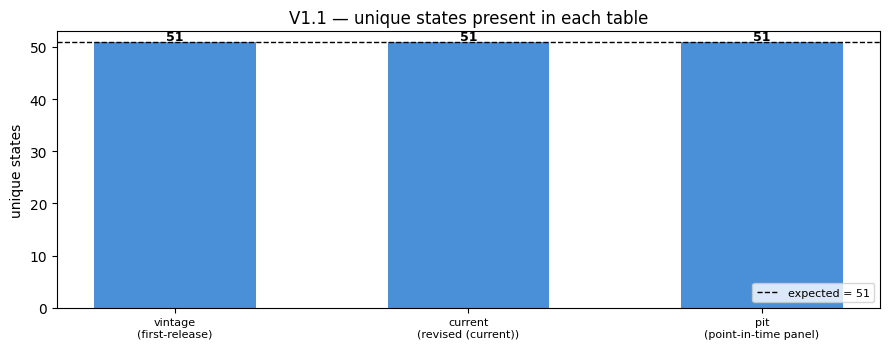

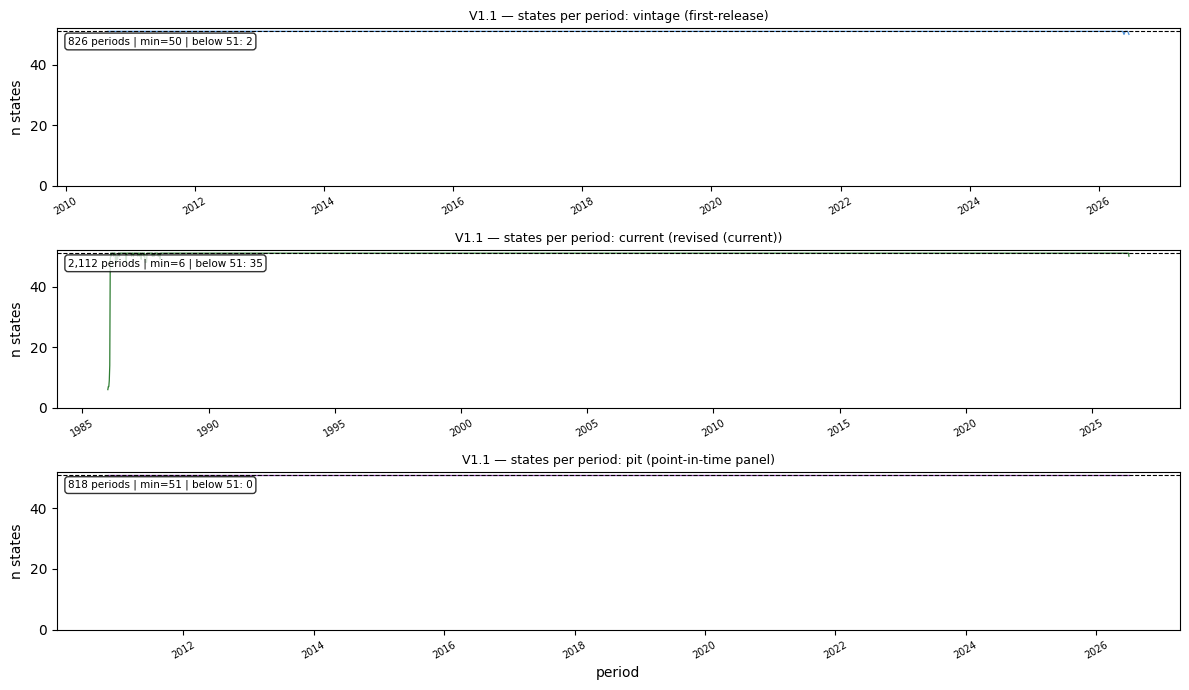

V1.1 — states per period summary (min / max / avg):
  vintage   min=50  max=51  avg= 51.0  below 51: 2  (first-release)
  current   min= 6  max=51  avg= 50.9  below 51: 35  (revised (current))
  pit       min=51  max=51  avg= 51.0  below 51: 0  (point-in-time panel)

V1.1 — periods with < 51 states (all dates):

  vintage (first-release): 2 period(s)
    2026-05-23 00:00:00  (50 states)
    2026-06-20 00:00:00  (50 states)

  current (revised (current)): 35 period(s)
    1986-01-04 00:00:00  (6 states)
    1986-01-11 00:00:00  (7 states)
    1986-01-18 00:00:00  (7 states)
    1986-01-25 00:00:00  (9 states)
    1986-02-01 00:00:00  (14 states)
    1986-02-08 00:00:00  (49 states)
    1986-02-22 00:00:00  (50 states)
    1986-03-29 00:00:00  (50 states)
    1986-04-26 00:00:00  (48 states)
    1986-05-03 00:00:00  (48 states)
    1986-05-10 00:00:00  (50 states)
    1986-05-17 00:00:00  (50 states)
    1986-05-24 00:00:00  (49 states)
    1986-05-31 00:00:00  (50 states)
    1986-06-21

In [9]:
# V1.1 — count unique states per dataset, then plot states reporting each period
N_EXPECTED = 51

_DATASETS = [
    ("vintage", cc_v, "obs_date", "#4a90d9", "first-release"),
    ("current", cc_c, "obs_date", "#2e7d32", "revised (current)"),
    ("pit",     pit, "as_of_date", "#8e44ad", "point-in-time panel"),
]

# (1) static universe: unique states in each table
n_states_tbl = {name: df["state"].nunique() for name, df, _, _, _ in _DATASETS}
print("V1.1 — unique states per table (criterion: 51 everywhere):")
for name, n in n_states_tbl.items():
    flag = "OK" if n == N_EXPECTED else "MISSING"
    print(f"  {name:8s}  {n:2d}  [{flag}]")

_labels = [f"{n}\n({tag})" for n, _, _, _, tag in _DATASETS]
_counts = [n_states_tbl[n] for n, _, _, _, _ in _DATASETS]
_colors = ["#4a90d9" if n == N_EXPECTED else "#d94a4a" for n in _counts]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=_colors, width=0.55)
ax.axhline(N_EXPECTED, color="black", ls="--", lw=1, label=f"expected = {N_EXPECTED}")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("unique states")
ax.set_ylim(0, N_EXPECTED + 2)
ax.set_title("V1.1 — unique states present in each table")
for bar, n in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 0.3, str(n),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# (2) states reporting per period over time (panel completeness by period)
per_period_stats = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, (name, df, date_col, color, tag) in zip(axes, _DATASETS):
    per = df.groupby(date_col)["state"].nunique().sort_index()
    per_period_stats[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(N_EXPECTED, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n states")
    ax.set_ylim(0, N_EXPECTED + 1)
    ax.set_title(f"V1.1 — states per period: {name} ({tag})", fontsize=9)
    below = int((per < N_EXPECTED).sum())
    ax.text(
        0.01, 0.95,
        f"{len(per):,} periods | min={per.min()} | below {N_EXPECTED}: {below}",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period")
plt.tight_layout(); plt.show()

print("V1.1 — states per period summary (min / max / avg):")
for name, _, _, _, tag in _DATASETS:
    per = per_period_stats[name]
    below = int((per < N_EXPECTED).sum())
    print(f"  {name:8s}  min={per.min():2d}  max={per.max():2d}  avg={per.mean():5.1f}  below {N_EXPECTED}: {below}  ({tag})")

print(f"\nV1.1 — periods with < {N_EXPECTED} states (all dates):")
for name, _, _, _, tag in _DATASETS:
    per = per_period_stats[name]
    incomplete = per[per < N_EXPECTED]
    print(f"\n  {name} ({tag}): {len(incomplete):,} period(s)")
    if incomplete.empty:
        print("    (none)")
    else:
        for dt, n in incomplete.items():
            print(f"    {dt}  ({int(n)} states)")

## V1.2 — Count and plot (state, claim_type, week) per dataset

V1.2 — (state, claim_type, week) key integrity (criterion: 0 duplicate rows):
  vintage   rows=84,248  unique keys=84,248  dup rows=0  [OK]  key=(state, claim_type, obs_date) (first-release)
  current   rows=214,909  unique keys=214,909  dup rows=0  [OK]  key=(state, claim_type, obs_date) (revised (current))
  pit       rows=41,718  unique keys=41,718  dup rows=0  [OK]  key=(as_of_date, state) (point-in-time panel)


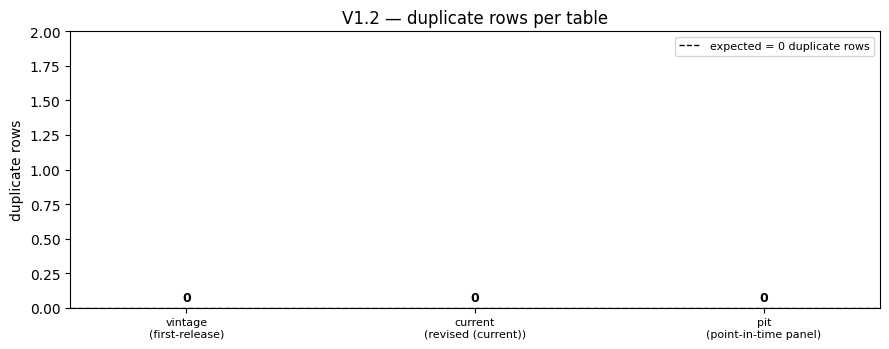

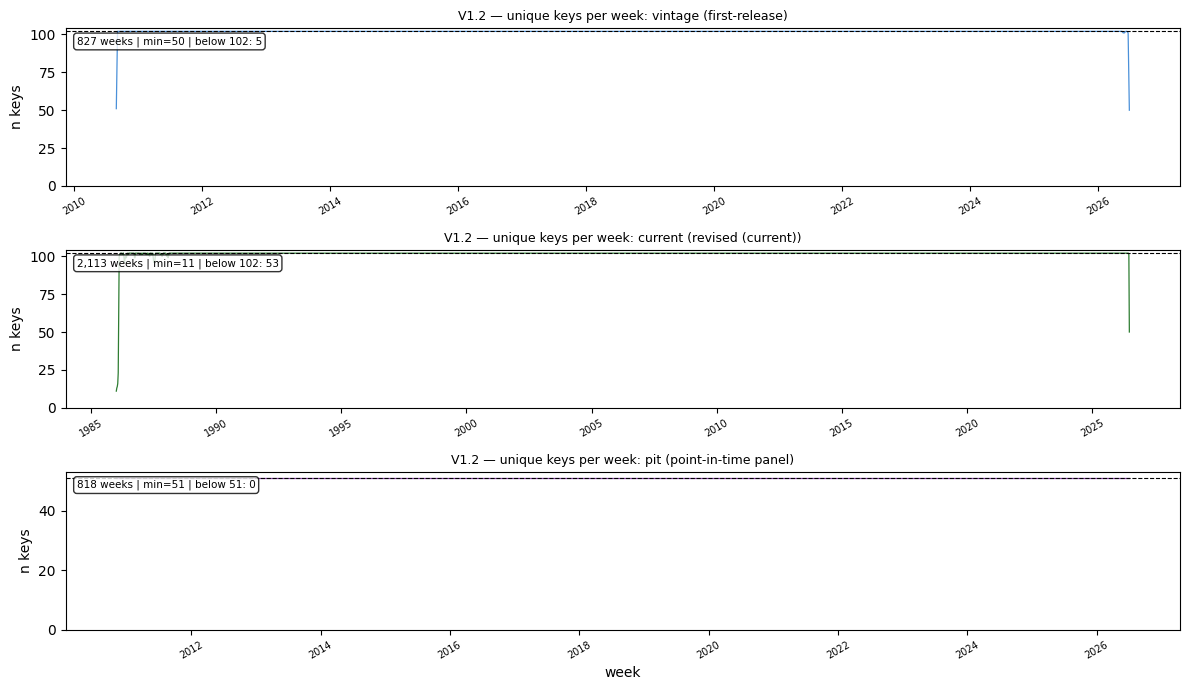

V1.2 — unique keys per week summary (min / max / avg):
  vintage   min= 50  max=102  avg= 101.9  below 102: 5  (first-release)
  current   min= 11  max=102  avg= 101.7  below 102: 53  (revised (current))
  pit       min= 51  max= 51  avg=  51.0  below 51: 0  (point-in-time panel)

V1.2 — weeks with < expected unique keys (all dates):

  vintage (first-release): 5 week(s) below 102
    2010-08-28 00:00:00  (51 keys)
    2026-05-23 00:00:00  (101 keys)
    2026-05-30 00:00:00  (101 keys)
    2026-06-20 00:00:00  (101 keys)
    2026-06-27 00:00:00  (50 keys)

  current (revised (current)): 53 week(s) below 102
    1986-01-04 00:00:00  (11 keys)
    1986-01-11 00:00:00  (13 keys)
    1986-01-18 00:00:00  (14 keys)
    1986-01-25 00:00:00  (16 keys)
    1986-02-01 00:00:00  (23 keys)
    1986-02-08 00:00:00  (63 keys)
    1986-02-15 00:00:00  (100 keys)
    1986-02-22 00:00:00  (101 keys)
    1986-03-01 00:00:00  (101 keys)
    1986-03-29 00:00:00  (101 keys)
    1986-04-05 00:00:00  (101 k

In [10]:
# V1.2 — count and plot (state, claim_type, week) keys per dataset
N_STATES = 51
N_CLAIM_TYPES = df_v["claim_type"].nunique()
EXPECTED_VC = N_STATES * N_CLAIM_TYPES  # 102 (state, claim_type) pairs per week

_DATASETS_V12 = [
    ("vintage", df_v, "obs_date", ["state", "claim_type", "obs_date"], EXPECTED_VC, "#4a90d9", "first-release"),
    ("current", df_c, "obs_date", ["state", "claim_type", "obs_date"], EXPECTED_VC, "#2e7d32", "revised (current)"),
    ("pit",     pit, "as_of_date", ["as_of_date", "state"], N_STATES, "#8e44ad", "point-in-time panel"),
]

# (1) static: row counts, unique keys, duplicate rows
_key_stats = {}
for name, df, _, key_cols, _, _, _ in _DATASETS_V12:
    dup_mask = df.duplicated(key_cols, keep=False)
    _key_stats[name] = {
        "rows": len(df),
        "unique": df.drop_duplicates(key_cols).shape[0],
        "dup_rows": int(dup_mask.sum()),
        "key_cols": key_cols,
    }

print("V1.2 — (state, claim_type, week) key integrity (criterion: 0 duplicate rows):")
for name, _, _, key_cols, expected, _, tag in _DATASETS_V12:
    s = _key_stats[name]
    key_label = "(state, claim_type, obs_date)" if "claim_type" in key_cols else "(as_of_date, state)"
    flag = "OK" if s["dup_rows"] == 0 else "DUP"
    print(
        f"  {name:8s}  rows={s['rows']:,}  unique keys={s['unique']:,}  "
        f"dup rows={s['dup_rows']}  [{flag}]  key={key_label} ({tag})"
    )

_labels = [f"{n}\n({tag})" for n, _, _, _, _, _, tag in _DATASETS_V12]
_dup_counts = [_key_stats[n]["dup_rows"] for n, _, _, _, _, _, _ in _DATASETS_V12]
_colors = ["#2e7d32" if d == 0 else "#d94a4a" for d in _dup_counts]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _dup_counts, color=_colors, width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 duplicate rows")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("duplicate rows")
ax.set_ylim(0, max(_dup_counts + [1]) + 1)
ax.set_title("V1.2 — duplicate rows per table")
for bar, d in zip(bars, _dup_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, d + 0.05, str(d),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# (2) unique keys per week over time
per_week_keys = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, (name, df, date_col, key_cols, expected, color, tag) in zip(axes, _DATASETS_V12):
    per = df.drop_duplicates(key_cols).groupby(date_col).size().sort_index()
    per_week_keys[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(expected, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n keys")
    ax.set_ylim(0, expected + 2)
    ax.set_title(f"V1.2 — unique keys per week: {name} ({tag})", fontsize=9)
    below = int((per < expected).sum())
    ax.text(
        0.01, 0.95,
        f"{len(per):,} weeks | min={per.min()} | below {expected}: {below}",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("week")
plt.tight_layout(); plt.show()

print("V1.2 — unique keys per week summary (min / max / avg):")
for name, _, _, _, expected, _, tag in _DATASETS_V12:
    per = per_week_keys[name]
    below = int((per < expected).sum())
    print(
        f"  {name:8s}  min={per.min():3d}  max={per.max():3d}  avg={per.mean():6.1f}  "
        f"below {expected}: {below}  ({tag})"
    )

print(f"\nV1.2 — weeks with < expected unique keys (all dates):")
for name, df, date_col, key_cols, expected, _, tag in _DATASETS_V12:
    per = per_week_keys[name]
    incomplete = per[per < expected]
    print(f"\n  {name} ({tag}): {len(incomplete):,} week(s) below {expected}")
    if incomplete.empty:
        print("    (none)")
    else:
        for dt, n in incomplete.items():
            print(f"    {dt}  ({int(n)} keys)")

print("\nV1.2 — duplicate key instances (all):")
for name, df, _, key_cols, _, _, tag in _DATASETS_V12:
    dup_mask = df.duplicated(key_cols, keep=False)
    print(f"\n  {name} ({tag}): {int(dup_mask.sum())} duplicate row(s)")
    if not dup_mask.any():
        print("    (none)")
    else:
        dup_keys = (
            df.loc[dup_mask, key_cols]
            .value_counts()
            .rename("n_rows")
            .reset_index()
            .sort_values(key_cols)
        )
        print(dup_keys.to_string(index=False))

## V1.3 — Count and plot nulls in the key fields

V1.3 — nulls in key fields (criterion: 0 nulls in vintage + current check fields):

  vintage (first-release): 0 null(s) in check fields  [OK]
    state                   0
    claim_type              0
    obs_date                0
    first_release_date      0
    value_first_release     0

  current (revised (current)): 0 null(s) in check fields  [OK]
    state                   0
    claim_type              0
    obs_date                0
    value_current           0

  pit (point-in-time panel): 0 null(s) in check fields  [OK]
    as_of_date              0
    state                   0


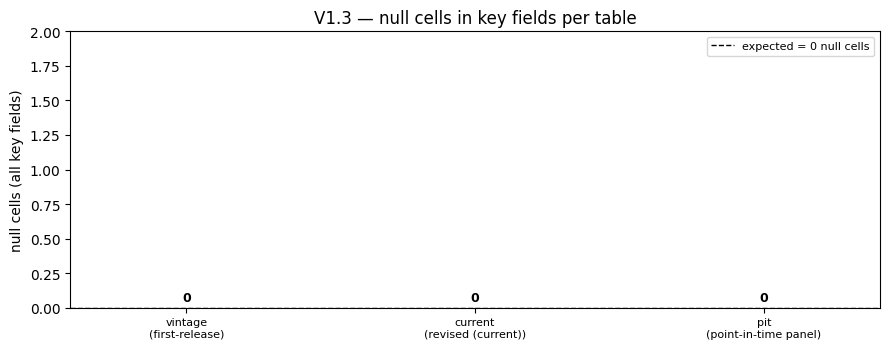

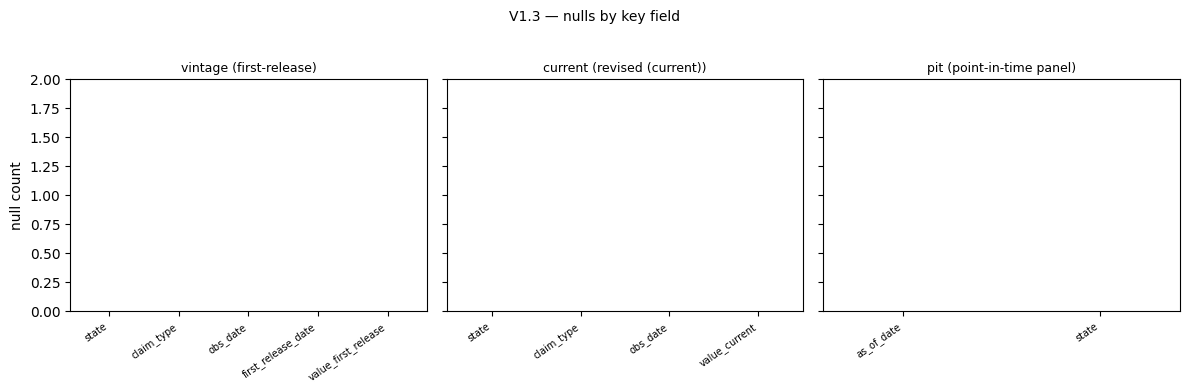

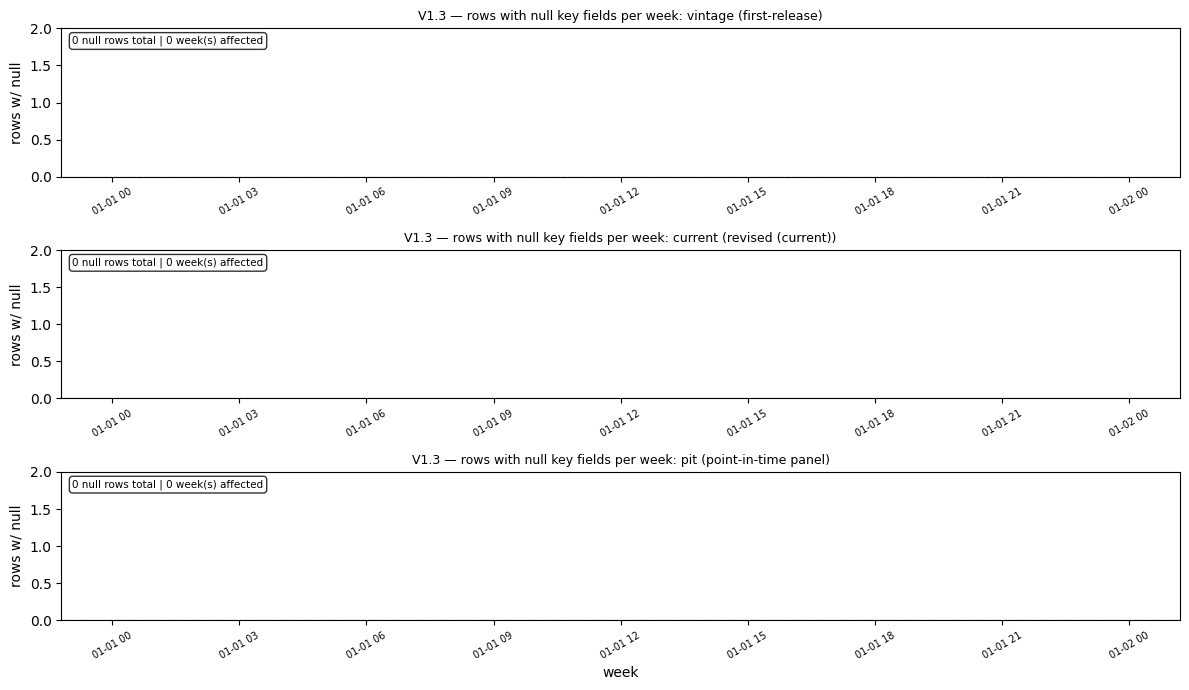

V1.3 — null rows summary:
  vintage   null rows=0  weeks w/ nulls=0  (first-release)
  current   null rows=0  weeks w/ nulls=0  (revised (current))
  pit       null rows=0  weeks w/ nulls=0  (point-in-time panel)

V1.3 — rows with null key fields (all):

  vintage (first-release): 0 row(s)
    (none)

  current (revised (current)): 0 row(s)
    (none)

  pit (point-in-time panel): 0 row(s)
    (none)


In [11]:
# V1.3 — count and plot nulls in key fields per dataset
_KEY_FIELDS_V13 = {
    "vintage": ["state", "claim_type", "obs_date", "first_release_date", "value_first_release"],
    "current": ["state", "claim_type", "obs_date", "value_current"],
    "pit": ["as_of_date", "state"],
}
_CHECK_FIELDS_V13 = {
    "vintage": ["state", "obs_date", "first_release_date", "value_first_release"],
    "current": ["state", "obs_date", "value_current"],
}
_DATE_COL_V13 = {"vintage": "obs_date", "current": "obs_date", "pit": "as_of_date"}
_COLORS_V13 = {"vintage": "#4a90d9", "current": "#2e7d32", "pit": "#8e44ad"}
_TAGS_V13 = {"vintage": "first-release", "current": "revised (current)", "pit": "point-in-time panel"}
_DFS_V13 = {"vintage": df_v, "current": df_c, "pit": pit}

# (1) static: null counts per key field
_null_by_field = {}
_null_rows = {}
for name, fields in _KEY_FIELDS_V13.items():
    df = _DFS_V13[name]
    _null_by_field[name] = df[fields].isna().sum()
    _null_rows[name] = int(df[fields].isna().any(axis=1).sum())

print("V1.3 — nulls in key fields (criterion: 0 nulls in vintage + current check fields):")
for name in _KEY_FIELDS_V13:
    check_fields = _CHECK_FIELDS_V13.get(name, _KEY_FIELDS_V13[name])
    check_nulls = int(_DFS_V13[name][check_fields].isna().sum().sum())
    flag = "OK" if check_nulls == 0 else "NULL"
    print(f"\n  {name} ({_TAGS_V13[name]}): {check_nulls} null(s) in check fields  [{flag}]")
    for field, n in _null_by_field[name].items():
        print(f"    {field:22s}  {int(n):,}")

# bar chart: total null cells per table
_labels = [f"{n}\n({_TAGS_V13[n]})" for n in _KEY_FIELDS_V13]
_totals = [int(_null_by_field[n].sum()) for n in _KEY_FIELDS_V13]
_colors = ["#2e7d32" if t == 0 else "#d94a4a" for t in _totals]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _totals, color=_colors, width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 null cells")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("null cells (all key fields)")
ax.set_ylim(0, max(_totals + [1]) + 1)
ax.set_title("V1.3 — null cells in key fields per table")
for bar, t in zip(bars, _totals):
    ax.text(bar.get_x() + bar.get_width() / 2, t + 0.05, str(t),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# grouped bar chart: nulls by field within each dataset
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, name in zip(axes, _KEY_FIELDS_V13):
    counts = _null_by_field[name]
    x = range(len(counts))
    cols = ["#2e7d32" if v == 0 else "#d94a4a" for v in counts.values]
    ax.bar(x, counts.values, color=cols, width=0.65)
    ax.set_xticks(x)
    ax.set_xticklabels(counts.index, rotation=35, ha="right", fontsize=7)
    ax.set_title(f"{name} ({_TAGS_V13[name]})", fontsize=9)
    ax.set_ylim(0, max(_totals + [1]) + 1)
    for i, v in enumerate(counts.values):
        if v:
            ax.text(i, v + 0.05, str(int(v)), ha="center", fontsize=8, fontweight="bold")
axes[0].set_ylabel("null count")
fig.suptitle("V1.3 — nulls by key field", fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

# (2) rows with any null key field per week over time
per_week_null_rows = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, name in zip(axes, _KEY_FIELDS_V13):
    df = _DFS_V13[name]
    fields = _KEY_FIELDS_V13[name]
    date_col = _DATE_COL_V13[name]
    null_mask = df[fields].isna().any(axis=1)
    per = df.loc[null_mask].groupby(date_col).size().sort_index()
    per_week_null_rows[name] = per
    ax.plot(per.index, per.values, color=_COLORS_V13[name], lw=0.9)
    ax.axhline(0, color="black", ls="--", lw=0.8)
    ax.set_ylabel("rows w/ null")
    ax.set_ylim(0, max(per.max() if len(per) else 0, 1) + 1)
    ax.set_title(f"V1.3 — rows with null key fields per week: {name} ({_TAGS_V13[name]})", fontsize=9)
    ax.text(
        0.01, 0.95,
        f"{_null_rows[name]:,} null rows total | {len(per):,} week(s) affected",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("week")
plt.tight_layout(); plt.show()

print("V1.3 — null rows summary:")
for name in _KEY_FIELDS_V13:
    print(
        f"  {name:8s}  null rows={_null_rows[name]:,}  "
        f"weeks w/ nulls={len(per_week_null_rows[name]):,}  ({_TAGS_V13[name]})"
    )

print("\nV1.3 — rows with null key fields (all):")
for name in _KEY_FIELDS_V13:
    df = _DFS_V13[name]
    fields = _KEY_FIELDS_V13[name]
    bad = df[df[fields].isna().any(axis=1)]
    print(f"\n  {name} ({_TAGS_V13[name]}): {len(bad):,} row(s)")
    if bad.empty:
        print("    (none)")
    else:
        show_cols = fields + [c for c in df.columns if c not in fields][:3]
        print(bad[show_cols].head(50).to_string(index=False))
        if len(bad) > 50:
            print(f"    ... {len(bad) - 50:,} more row(s)")

## V1.4 — Values parseable, finite and positive


V1.4 — values parseable, finite and positive (criterion: 0 bad; startup-era zeros → WARN):
  vintage   bad rows=0  [OK]  (first-release)
  current   bad rows=15  [BAD]  (revised (current))
  current zeros (<=0): 15  latest=1986-07-19  post-1990=0


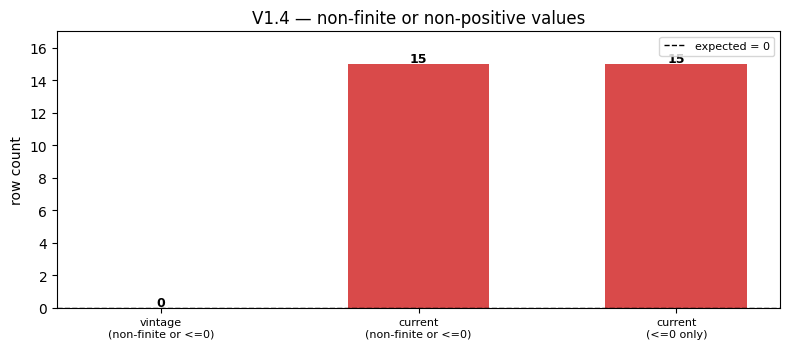

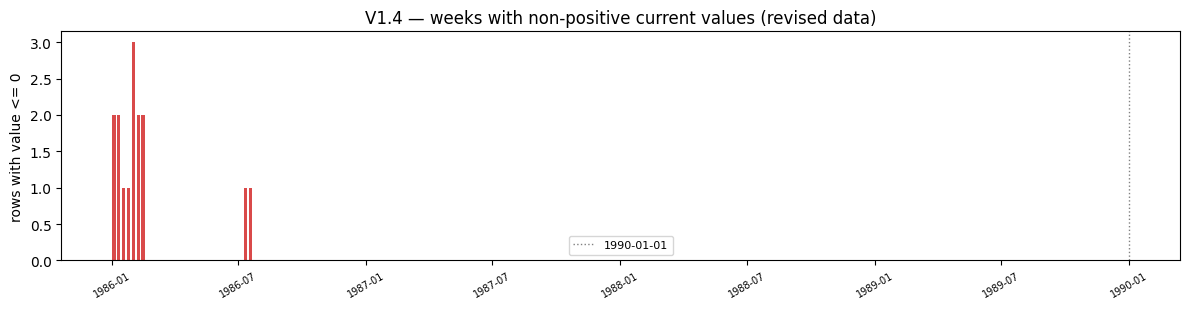


V1.4 — all non-finite or non-positive rows (vintage):
  (none)

V1.4 — all non-positive rows (current, value <= 0):
     state claim_type   obs_date  value_current
  Colorado    cclaims 1986-01-04            0.0
  Colorado    cclaims 1986-01-11            0.0
  Colorado    cclaims 1986-01-25            0.0
  Colorado    cclaims 1986-02-01            0.0
  Colorado    iclaims 1986-01-04            0.0
  Colorado    iclaims 1986-01-11            0.0
  Colorado    iclaims 1986-01-18            0.0
  Colorado    iclaims 1986-02-01            0.0
  Colorado    iclaims 1986-02-08            0.0
      Iowa    cclaims 1986-02-01            0.0
      Iowa    iclaims 1986-02-08            0.0
New Jersey    iclaims 1986-07-12            0.0
New Jersey    iclaims 1986-07-19            0.0
New Mexico    iclaims 1986-02-15            0.0
  Virginia    iclaims 1986-02-15            0.0


In [12]:
# V1.4 — values parseable, finite and positive (incl. FRED int→float drift)
_VAL_COLS_V14 = {
    "vintage": ("value_first_release", df_v, "obs_date", "#4a90d9", "first-release"),
    "current": ("value_current", df_c, "obs_date", "#2e7d32", "revised (current)"),
}

def _bad_mask(series):
    return ~series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and np.isfinite(x) and x > 0)

_bad_rows = {}
for name, (col, df, date_col, color, tag) in _VAL_COLS_V14.items():
    mask = _bad_mask(df[col])
    _bad_rows[name] = df.loc[mask, ["state", "claim_type", date_col, col]].copy()
    _bad_rows[name].rename(columns={date_col: "obs_date", col: "value"}, inplace=True)

nonpos = df_c[df_c["value_current"] <= 0].copy()
nonpos_recent = nonpos[nonpos["obs_date"] >= "1990-01-01"]
bad_v = len(_bad_rows["vintage"])
bad_c = len(_bad_rows["current"])
n_nonpos = len(nonpos)

print("V1.4 — values parseable, finite and positive (criterion: 0 bad; startup-era zeros → WARN):")
for name, (_, _, _, _, tag) in _VAL_COLS_V14.items():
    n = len(_bad_rows[name])
    flag = "OK" if n == 0 else "BAD"
    print(f"  {name:8s}  bad rows={n:,}  [{flag}]  ({tag})")
print(f"  current zeros (<=0): {n_nonpos:,}  latest={nonpos['obs_date'].max().date() if n_nonpos else 'n/a'}  post-1990={len(nonpos_recent)}")

# bar chart: bad / non-positive counts
_labels = ["vintage\n(non-finite or <=0)", "current\n(non-finite or <=0)", "current\n(<=0 only)"]
_counts = [bad_v, bad_c, n_nonpos]
_colors = ["#2e7d32" if c == 0 else "#d94a4a" for c in _counts]

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=_colors, width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("row count")
ax.set_ylim(0, max(_counts + [1]) + 2)
ax.set_title("V1.4 — non-finite or non-positive values")
for bar, c in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 0.1, str(c),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# time series: weeks with any <=0 current value
_nonpos_by_week = nonpos.groupby("obs_date").size().sort_index()
fig, ax = plt.subplots(figsize=(12, 3.2))
if len(_nonpos_by_week):
    ax.bar(_nonpos_by_week.index, _nonpos_by_week.values, color="#d94a4a", width=5)
ax.axvline(pd.Timestamp("1990-01-01"), color="gray", ls=":", lw=1, label="1990-01-01")
ax.set_ylabel("rows with value <= 0")
ax.set_title("V1.4 — weeks with non-positive current values (revised data)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelrotation=30, labelsize=7)
plt.tight_layout(); plt.show()

print("\nV1.4 — all non-finite or non-positive rows (vintage):")
if bad_v == 0:
    print("  (none)")
else:
    print(_bad_rows["vintage"].sort_values(["state", "claim_type", "obs_date"]).to_string(index=False))

print("\nV1.4 — all non-positive rows (current, value <= 0):")
if n_nonpos == 0:
    print("  (none)")
else:
    print(
        nonpos[["state", "claim_type", "obs_date", "value_current"]]
        .sort_values(["state", "claim_type", "obs_date"])
        .to_string(index=False)
    )


## V1.4b — Zero position: leading (ramp-in) vs interior (dropout)


V1.4b — zero position (criterion: interior == 0 ideally; pre-1990 interior → WARN):
  leading (ramp-in):  9
  interior (dropout): 6  (post-1990: 0)

V1.4b — zeros by state / claim_type:
     state claim_type  interior  leading  total_zeros
  Colorado    cclaims         2        2            4
  Colorado    iclaims         2        3            5
      Iowa    cclaims         0        1            1
      Iowa    iclaims         0        1            1
New Jersey    iclaims         2        0            2
New Mexico    iclaims         0        1            1
  Virginia    iclaims         0        1            1


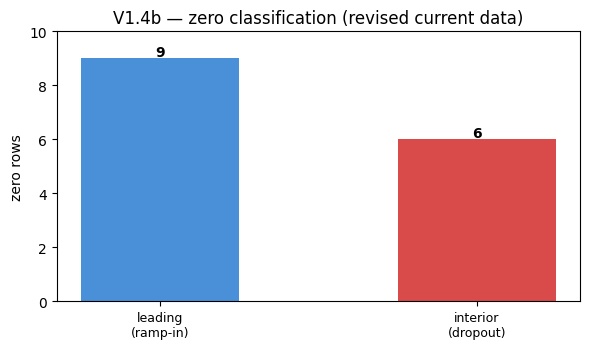


V1.4b — all zero rows with position:
     state claim_type   obs_date position
  Colorado    cclaims 1986-01-25 interior
  Colorado    cclaims 1986-02-01 interior
  Colorado    iclaims 1986-02-01 interior
  Colorado    iclaims 1986-02-08 interior
New Jersey    iclaims 1986-07-12 interior
New Jersey    iclaims 1986-07-19 interior
  Colorado    cclaims 1986-01-04  leading
  Colorado    cclaims 1986-01-11  leading
  Colorado    iclaims 1986-01-04  leading
  Colorado    iclaims 1986-01-11  leading
  Colorado    iclaims 1986-01-18  leading
      Iowa    cclaims 1986-02-01  leading
      Iowa    iclaims 1986-02-08  leading
New Mexico    iclaims 1986-02-15  leading
  Virginia    iclaims 1986-02-15  leading


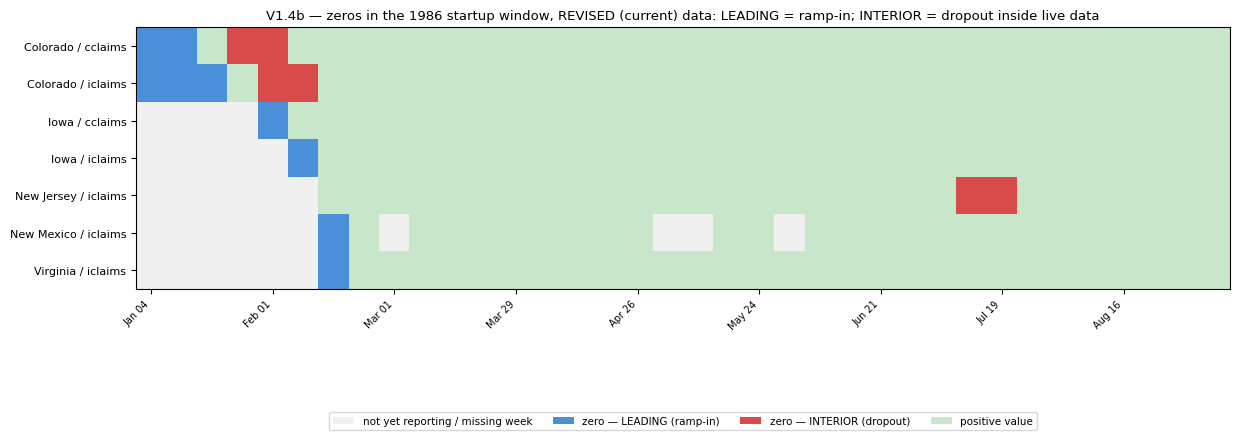

In [13]:
# V1.4b — zero position: leading (ramp-in) vs interior (mid-sample dropout)
zero_class = []
for (state, ct), g in df_c.groupby(["state", "claim_type"]):
    z = g[g["value_current"] <= 0]
    if not len(z):
        continue
    first_nonzero = g.loc[g["value_current"] > 0, "obs_date"].min()
    for _, r in z.iterrows():
        zero_class.append({
            "state": state, "claim_type": ct, "obs_date": r["obs_date"],
            "position": "leading" if r["obs_date"] < first_nonzero else "interior",
        })
zero_class = pd.DataFrame(zero_class)

n_lead = int((zero_class["position"] == "leading").sum()) if len(zero_class) else 0
n_int = int((zero_class["position"] == "interior").sum()) if len(zero_class) else 0
int_recent = (
    zero_class[(zero_class["position"] == "interior") & (zero_class["obs_date"] >= "1990-01-01")]
    if len(zero_class) else zero_class
)

print("V1.4b — zero position (criterion: interior == 0 ideally; pre-1990 interior → WARN):")
print(f"  leading (ramp-in):  {n_lead}")
print(f"  interior (dropout): {n_int}  (post-1990: {len(int_recent)})")

# summary table by (state, claim_type)
if len(zero_class):
    _zc_summary = (
        zero_class.groupby(["state", "claim_type", "position"]).size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for col in ["leading", "interior"]:
        if col not in _zc_summary.columns:
            _zc_summary[col] = 0
    _zc_summary["total_zeros"] = _zc_summary["leading"] + _zc_summary["interior"]
    print("\nV1.4b — zeros by state / claim_type:")
    print(_zc_summary.sort_values(["state", "claim_type"]).to_string(index=False))
else:
    print("\n  (no zeros)")

# bar chart: leading vs interior
_pos_labels = ["leading\n(ramp-in)", "interior\n(dropout)"]
_pos_counts = [n_lead, n_int]
_pos_colors = ["#4a90d9", "#d94a4a" if n_int else "#2e7d32"]

fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar(range(2), _pos_counts, color=_pos_colors, width=0.5)
ax.set_xticks(range(2))
ax.set_xticklabels(_pos_labels, fontsize=9)
ax.set_ylabel("zero rows")
ax.set_ylim(0, max(_pos_counts + [1]) + 1)
ax.set_title("V1.4b — zero classification (revised current data)")
for bar, c in zip(bars, _pos_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 0.1, str(c),
            ha="center", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nV1.4b — all zero rows with position:")
if len(zero_class):
    print(zero_class.sort_values(["position", "state", "claim_type", "obs_date"]).to_string(index=False))
else:
    print("  (none)")

# heatmap: 1986 startup window
if len(zero_class):
    from matplotlib.colors import ListedColormap, BoundaryNorm
    from matplotlib.patches import Patch

    pairs = sorted({(r.state, r.claim_type) for r in zero_class.itertuples()})
    weeks = pd.date_range("1986-01-04", "1986-09-06", freq="W-SAT")
    M = np.zeros((len(pairs), len(weeks)))
    for r_i, (st, ct) in enumerate(pairs):
        g = df_c[(df_c["state"] == st) & (df_c["claim_type"] == ct)].set_index("obs_date")["value_current"]
        first_nonzero = g[g > 0].index.min()
        for c_i, w in enumerate(weeks):
            if w in g.index:
                v = g.loc[w]
                if v > 0:
                    M[r_i, c_i] = 3
                else:
                    M[r_i, c_i] = 1 if w < first_nonzero else 2
    cmap = ListedColormap(["#f0f0f0", "#4a90d9", "#d94a4a", "#c8e6c9"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
    fig, ax = plt.subplots(figsize=(12.5, 0.5 * len(pairs) + 1.6))
    ax.imshow(M, aspect="auto", cmap=cmap, norm=norm)
    ax.set_yticks(range(len(pairs)))
    ax.set_yticklabels([f"{s} / {c}" for s, c in pairs], fontsize=8)
    ax.set_xticks(range(0, len(weeks), 4))
    ax.set_xticklabels([w.strftime("%b %d") for w in weeks[::4]], rotation=45, ha="right", fontsize=7)
    ax.set_title(
        "V1.4b — zeros in the 1986 startup window, REVISED (current) data: "
        "LEADING = ramp-in; INTERIOR = dropout inside live data",
        fontsize=9.5,
    )
    ax.legend(
        handles=[
            Patch(fc="#f0f0f0", label="not yet reporting / missing week"),
            Patch(fc="#4a90d9", label="zero — LEADING (ramp-in)"),
            Patch(fc="#d94a4a", label="zero — INTERIOR (dropout)"),
            Patch(fc="#c8e6c9", label="positive value"),
        ],
        fontsize=7.5, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.45),
    )
    plt.tight_layout(); plt.show()


cc_v missing cells — by obs_date: 2 of 42,126 (0.00%)
cc_v missing cells — by first_release_date: 5,692 of 47,481 (11.99%)


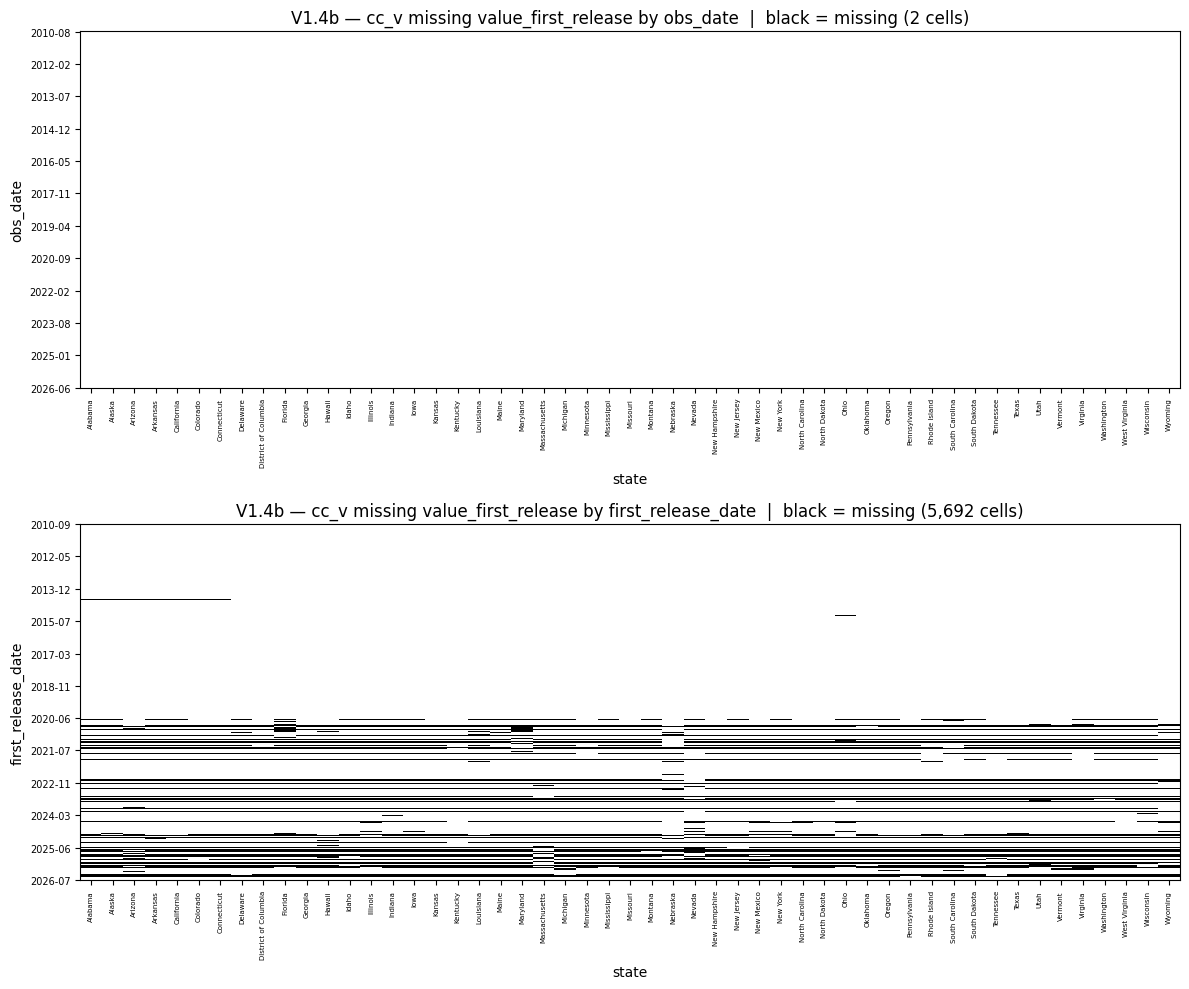

In [20]:
# V1.4b — cc_v missing-value heatmaps (obs_date vs first_release_date grids)
_states_sorted = sorted(cc_v["state"].unique())

_pivots = [
    ("obs_date", cc_v.pivot_table(index="obs_date", columns="state", values="value_first_release")),
    ("first_release_date", cc_v.pivot_table(index="first_release_date", columns="state", values="value_first_release")),
]

for label, wide in _pivots:
    wide = wide.reindex(columns=_states_sorted).sort_index()
    missing = wide.isna()
    print(f"cc_v missing cells — by {label}: {int(missing.values.sum()):,} of {missing.size:,} "
          f"({missing.values.mean():.2%})")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, (label, wide) in zip(axes, _pivots):
    wide = wide.reindex(columns=_states_sorted).sort_index()
    missing = wide.isna()
    cal = missing.index
    n_miss = int(missing.values.sum())
    ax.imshow(missing.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
    ax.set_xticks(range(len(_states_sorted)))
    ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
    _yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
    ax.set_yticks(_yt)
    ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
    ax.set_xlabel("state")
    ax.set_ylabel(label)
    ax.set_title(f"V1.4b — cc_v missing value_first_release by {label}  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()

cc_c missing cells — by obs_date: 260 of 107,712 (0.24%)


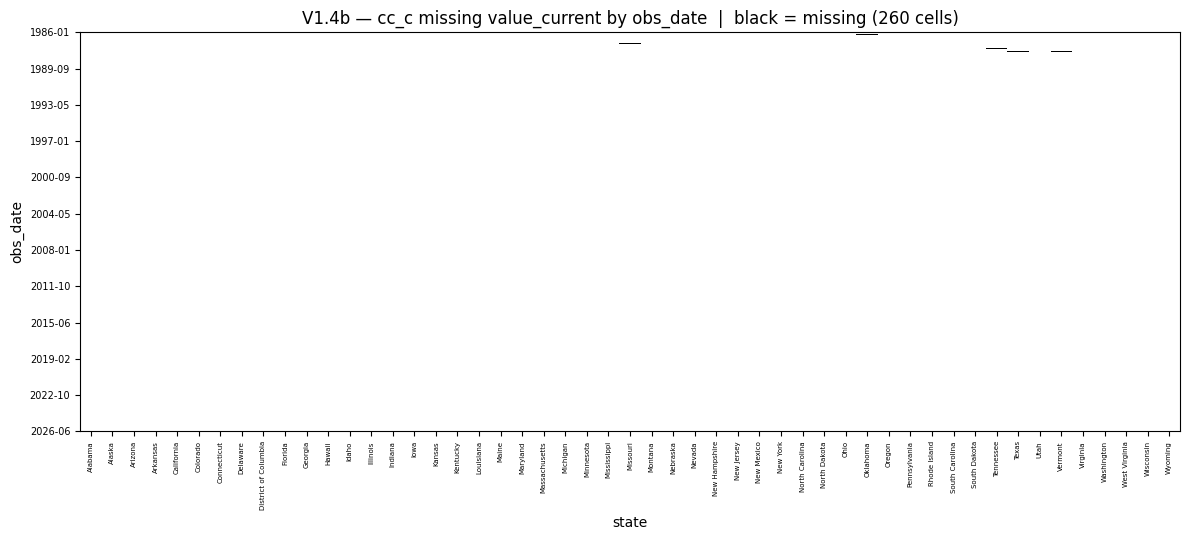

In [21]:
# V1.4b — cc_c missing-value heatmap (obs_date grid, revised current history)
_states_sorted = sorted(cc_c["state"].unique())

wide_c = cc_c.pivot_table(index="obs_date", columns="state", values="value_current")
wide_c = wide_c.reindex(columns=_states_sorted).sort_index()
missing_c = wide_c.isna()

print(f"cc_c missing cells — by obs_date: {int(missing_c.values.sum()):,} of {missing_c.size:,} "
      f"({missing_c.values.mean():.2%})")

fig, ax = plt.subplots(figsize=(12, 5.5))
cal = missing_c.index
n_miss = int(missing_c.values.sum())
ax.imshow(missing_c.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(_states_sorted)))
ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
_yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
ax.set_yticks(_yt)
ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
ax.set_xlabel("state")
ax.set_ylabel("obs_date")
ax.set_title(f"V1.4b — cc_c missing value_current by obs_date  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


pit missing cells — iclaims_t0 by as_of_date: 0 of 41,718 (0.00%)


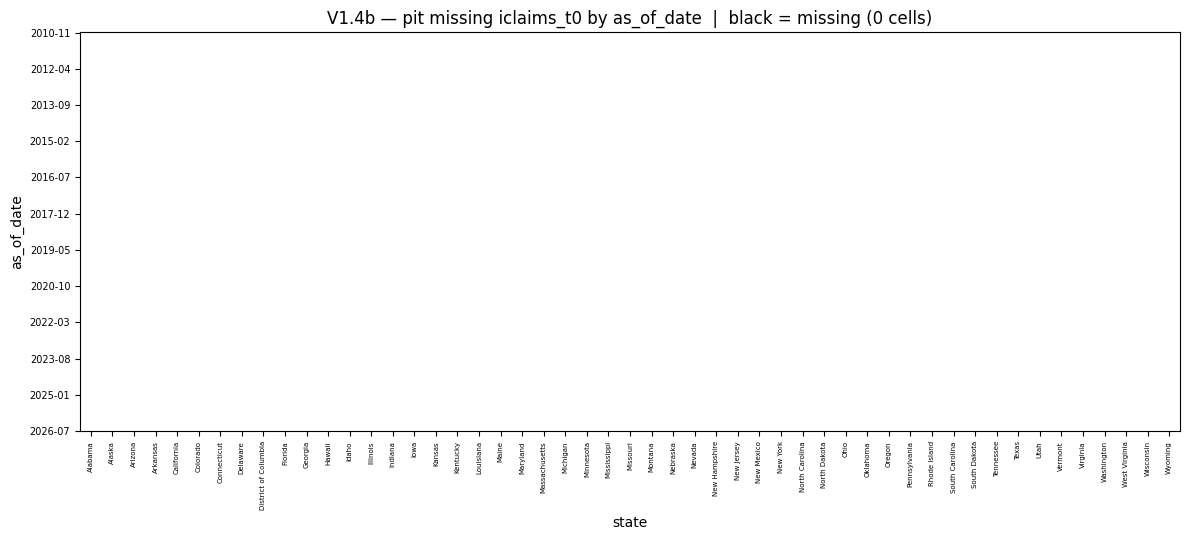

In [22]:
# V1.4b — pit missing-value heatmap (as_of_date grid, iclaims_t0)
_states_sorted = sorted(pit["state"].unique())

wide_pit = pit.pivot_table(index="as_of_date", columns="state", values="iclaims_t0")
wide_pit = wide_pit.reindex(columns=_states_sorted).sort_index()
missing_pit = wide_pit.isna()

print(f"pit missing cells — iclaims_t0 by as_of_date: {int(missing_pit.values.sum()):,} of {missing_pit.size:,} "
      f"({missing_pit.values.mean():.2%})")

fig, ax = plt.subplots(figsize=(12, 5.5))
cal = missing_pit.index
n_miss = int(missing_pit.values.sum())
ax.imshow(missing_pit.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(_states_sorted)))
ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
_yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
ax.set_yticks(_yt)
ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
ax.set_xlabel("state")
ax.set_ylabel("as_of_date")
ax.set_title(f"V1.4b — pit missing iclaims_t0 by as_of_date  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


## V1.5 — Row counts per state (fetch truncation check)


V1.5 — row counts per state, continued-claims current history
  (criterion: max - min <= 15 weeks; spread=12)
  min=2100  max=2112  median=2107  n_states=51

V1.5 — rows per state (sorted ascending):
               state  n_rows  vs_median
          New Mexico    2100       -7.0
              Nevada    2103       -4.0
          California    2103       -4.0
             Vermont    2103       -4.0
            Oklahoma    2103       -4.0
              Hawaii    2103       -4.0
           Louisiana    2104       -3.0
            Missouri    2105       -2.0
          New Jersey    2106       -1.0
      North Carolina    2106       -1.0
                Ohio    2106       -1.0
        Rhode Island    2106       -1.0
           Tennessee    2106       -1.0
            Delaware    2106       -1.0
              Alaska    2106       -1.0
           Wisconsin    2106       -1.0
            Nebraska    2107        0.0
        Pennsylvania    2107        0.0
              Oregon    2107        0.0


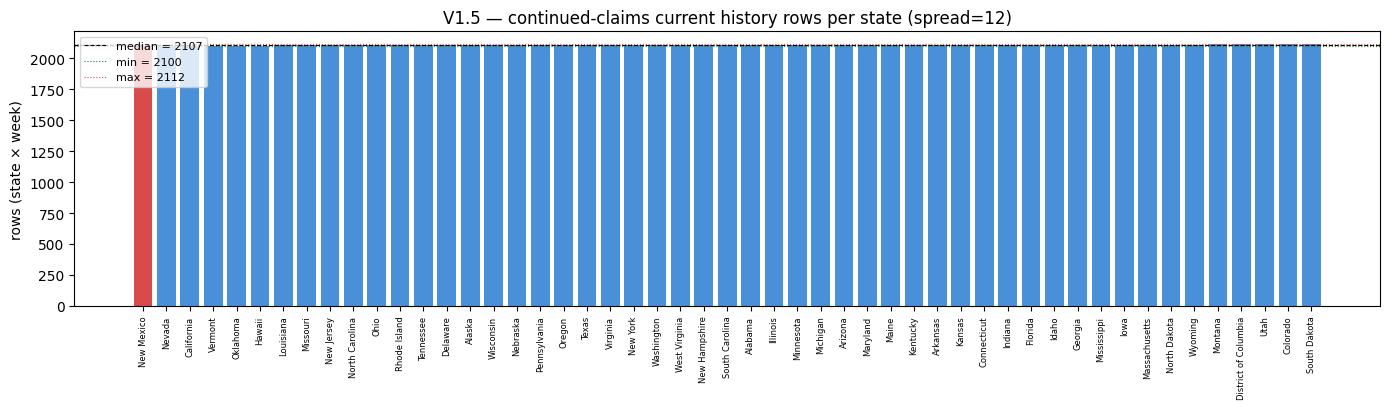

In [14]:
# V1.5 — row counts per state (fetch truncation check)
rc = cc_c.groupby("state").size().sort_values()
rc_min, rc_max = int(rc.min()), int(rc.max())
rc_spread = rc_max - rc_min
rc_median = float(rc.median())

print("V1.5 — row counts per state, continued-claims current history")
print(f"  (criterion: max - min <= 15 weeks; spread={rc_spread})")
print(f"  min={rc_min}  max={rc_max}  median={rc_median:.0f}  n_states={len(rc)}")

# table: all states sorted by row count
_rc_tbl = rc.reset_index(name="n_rows")
_rc_tbl["vs_median"] = _rc_tbl["n_rows"] - rc_median
print("\nV1.5 — rows per state (sorted ascending):")
print(_rc_tbl.to_string(index=False))

# highlight outliers (>5 weeks from median)
_outliers = _rc_tbl[_rc_tbl["vs_median"].abs() > 5]
print(f"\nV1.5 — states >5 weeks from median ({len(_outliers)}):")
if _outliers.empty:
    print("  (none)")
else:
    print(_outliers.to_string(index=False))

# bar chart
_states = rc.index.tolist()
_counts = rc.values
_colors = ["#d94a4a" if (v - rc_median) < -5 or (v - rc_median) > 5 else "#4a90d9" for v in _counts]

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.bar(range(len(_states)), _counts, color=_colors, width=0.8)
ax.axhline(rc_median, color="black", ls="--", lw=0.8, label=f"median = {rc_median:.0f}")
ax.axhline(rc_min, color="#2e7d32", ls=":", lw=0.8, label=f"min = {rc_min}")
ax.axhline(rc_max, color="#d94a4a", ls=":", lw=0.8, label=f"max = {rc_max}")
ax.set_xticks(range(len(_states)))
ax.set_xticklabels(_states, rotation=90, fontsize=6)
ax.set_ylabel("rows (state × week)")
ax.set_title(f"V1.5 — continued-claims current history rows per state (spread={rc_spread})")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()


## V2 — Calendar & frequency — *observation time: the week being measured*

This module validates the **observation clock**: `obs_date` stamps the reference week (always ending **Saturday**,  U.S. Department of Labor (DOL) convention). It says *what* the number measures — not when anyone knew it. The information clock (when the number became known) is V3's subject.

| Check | Question it answers |
|---|---|
| V2.1 | Do all observation dates follow the DOL Saturday week-ending convention? |
| V2.2a | Are there missing weeks in the old (pre-1990) history? |
| V2.2b | Are there missing weeks in modern data — live issues to monitor? |
| V2.3 | Do all states cover the same window (balanced panel)? |

## V2.1 — DOL Saturday week-ending convention


V2.1 — obs_date weekday (criterion: all Saturdays, dayofweek == 5):
  vintage  (first-release):  non-Saturday obs_date rows=0  [OK]
  current  (revised (current)):  non-Saturday obs_date rows=0  [OK]

V2.1 — weekday distribution (unique obs_date counts):
  vintage (first-release):  Mon=0  Tue=0  Wed=0  Thu=0  Fri=0  Sat=827  Sun=0
  current (revised (current)):  Mon=0  Tue=0  Wed=0  Thu=0  Fri=0  Sat=2113  Sun=0


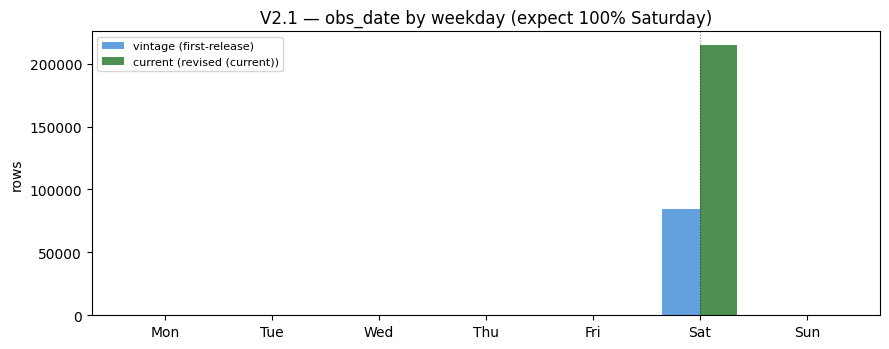


V2.1 — non-Saturday obs_dates (vintage, first-release):
  (none)

V2.1 — non-Saturday obs_dates (current, revised (current)):
  (none)
[PASS] V2.1   All obs_date are Saturdays (DOL week-ending)  |  vintage=0, current=0 non-Saturday  (criterion: == 0)


In [15]:
# V2.1 — all observation dates are Saturdays (DOL week-ending convention)
_DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
_DATASETS_V21 = [
    ("vintage", df_v, "#4a90d9", "first-release"),
    ("current", df_c, "#2e7d32", "revised (current)"),
]

_non_sat = {}
_dow_counts = {}
for name, df, color, tag in _DATASETS_V21:
    dow = df["obs_date"].dt.dayofweek
    _dow_counts[name] = dow.value_counts().sort_index()
    _non_sat[name] = df.loc[dow != 5, ["state", "claim_type", "obs_date"]].drop_duplicates()

print("V2.1 — obs_date weekday (criterion: all Saturdays, dayofweek == 5):")
for name, _, _, tag in _DATASETS_V21:
    n_bad = len(_non_sat[name])
    flag = "OK" if n_bad == 0 else "FAIL"
    print(f"  {name:8s} ({tag}):  non-Saturday obs_date rows={n_bad}  [{flag}]")

print("\nV2.1 — weekday distribution (unique obs_date counts):")
for name, df, _, tag in _DATASETS_V21:
    per_dow = df["obs_date"].drop_duplicates().dt.dayofweek.value_counts().sort_index()
    row = {_DOW_NAMES[d]: int(per_dow.get(d, 0)) for d in range(7)}
    print(f"  {name} ({tag}):  " + "  ".join(f"{k}={v}" for k, v in row.items()))

fig, ax = plt.subplots(figsize=(9, 3.6))
w = 0.35
x = np.arange(7)
for i, (name, _, color, tag) in enumerate(_DATASETS_V21):
    counts = [_dow_counts[name].get(d, 0) for d in range(7)]
    offset = -w / 2 if i == 0 else w / 2
    ax.bar(x + offset, counts, w, label=f"{name} ({tag})", color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(_DOW_NAMES)
ax.axvline(5, color="black", ls=":", lw=0.8, alpha=0.5)
ax.set_ylabel("rows")
ax.set_title("V2.1 — obs_date by weekday (expect 100% Saturday)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for name, _, _, tag in _DATASETS_V21:
    print(f"\nV2.1 — non-Saturday obs_dates ({name}, {tag}):")
    if _non_sat[name].empty:
        print("  (none)")
    else:
        print(_non_sat[name].sort_values(["obs_date", "state", "claim_type"]).to_string(index=False))

add_check("V2", "V2.1", "All obs_date are Saturdays (DOL week-ending)",
          "PASS" if all(len(_non_sat[n]) == 0 for n, *_ in _DATASETS_V21) else "FAIL",
          metric=f"vintage={len(_non_sat['vintage'])}, current={len(_non_sat['current'])} non-Saturday",
          threshold="== 0")


## V2.2a — Missing weeks in pre-1990 history


V2.2a — interior missing weeks, pre-1990 (criterion: 0 ideally; startup holes → WARN):
  missing weeks: 48  across 22 state(s)

V2.2a — pre-1990 gaps per state:
                n_gaps
state                 
New Mexico           7
Nevada               5
California           5
Vermont              4
Hawaii               4
Oklahoma             4
Louisiana            3
Missouri             2
Ohio                 1
Wisconsin            1
Texas                1
Tennessee            1
Rhode Island         1
Alaska               1
North Dakota         1
North Carolina       1
New Jersey           1
Massachusetts        1
Illinois             1
Delaware             1
Connecticut          1
Wyoming              1

V2.2a — all pre-1990 missing weeks:
         state missing_week
 Massachusetts   1986-02-01
      Illinois   1986-02-08
  North Dakota   1986-02-08
    New Mexico   1986-02-22
          Ohio   1986-03-29
     Louisiana   1986-04-26
    New Mexico   1986-04-26
      Oklahoma   1986-04-2

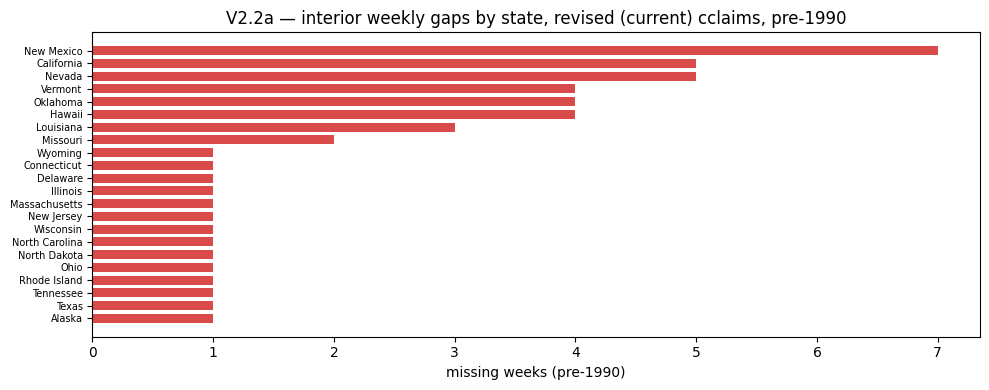

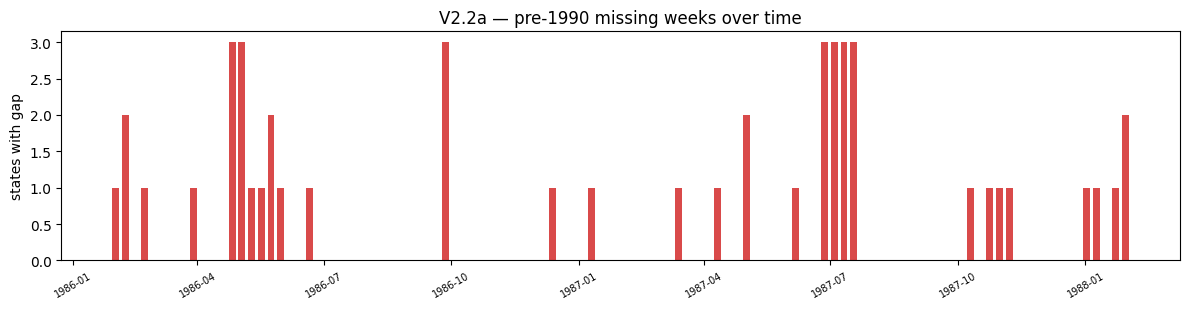

[WARN] V2.2a  Interior weekly gaps, pre-1990 startup era  |  48 missing weeks across 22 states (1986-88)  (criterion: 0 ideally; tolerated as WARN pre-1990)
       note: early DOL collection holes — RULE: forecasting pipelines must handle NaN weeks; do not forward-fill through gaps when computing WoW changes


In [16]:
# V2.2a — interior weekly gaps on the W-SAT calendar (pre-1990 startup era)
gap_rows = []
for state, g in cc_c.groupby("state"):
    cal = pd.date_range(g["obs_date"].min(), g["obs_date"].max(), freq="W-SAT")
    for d in cal.difference(g["obs_date"]):
        gap_rows.append({"state": state, "missing_week": d})
gaps_df = pd.DataFrame(gap_rows)
early_gaps = gaps_df[gaps_df["missing_week"] < "1990-01-01"].copy() if len(gaps_df) else gaps_df
recent_gaps = gaps_df[gaps_df["missing_week"] >= "1990-01-01"].copy() if len(gaps_df) else gaps_df

print("V2.2a — interior missing weeks, pre-1990 (criterion: 0 ideally; startup holes → WARN):")
print(f"  missing weeks: {len(early_gaps)}  across {early_gaps['state'].nunique() if len(early_gaps) else 0} state(s)")

if len(early_gaps):
    by_state = early_gaps.groupby("state").size().sort_values(ascending=False).rename("n_gaps")
    print("\nV2.2a — pre-1990 gaps per state:")
    print(by_state.to_frame().to_string())
    print("\nV2.2a — all pre-1990 missing weeks:")
    print(early_gaps.sort_values(["missing_week", "state"]).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    by_state = early_gaps.groupby("state").size().sort_values()
    ax.barh(range(len(by_state)), by_state.values, color="#d94a4a", height=0.7)
    ax.set_yticks(range(len(by_state)))
    ax.set_yticklabels(by_state.index, fontsize=7)
    ax.set_xlabel("missing weeks (pre-1990)")
    ax.set_title("V2.2a — interior weekly gaps by state, revised (current) cclaims, pre-1990")
    plt.tight_layout(); plt.show()

    per_week = early_gaps.groupby("missing_week").size()
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.bar(per_week.index, per_week.values, color="#d94a4a", width=5)
    ax.set_ylabel("states with gap")
    ax.set_title("V2.2a — pre-1990 missing weeks over time")
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
    plt.tight_layout(); plt.show()
else:
    print("  (none)")

add_check("V2", "V2.2a", "Interior weekly gaps, pre-1990 startup era",
          "PASS" if len(early_gaps) == 0 else "WARN",
          metric=f"{len(early_gaps)} missing weeks across {early_gaps['state'].nunique() if len(early_gaps) else 0} states (1986-88)",
          threshold="0 ideally; tolerated as WARN pre-1990",
          note="early DOL collection holes — RULE: forecasting pipelines must handle NaN weeks; "
               "do not forward-fill through gaps when computing WoW changes")


## V2.2b — Missing weeks in modern data (post-1990)


V2.2b — interior missing weeks, post-1990 (criterion: == 0; any gap must be investigated):
  missing weeks: 0  across 0 state(s)
  (none — clean modern panel)


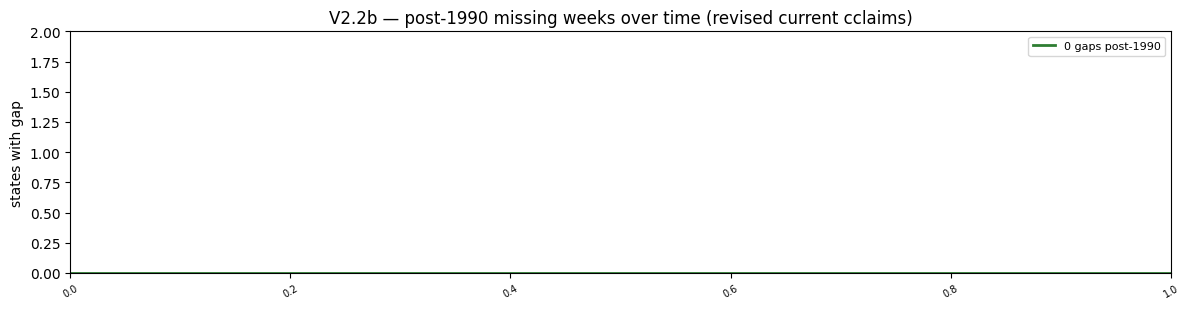

[PASS] V2.2b  Interior weekly gaps, post-1990 (live data issues)  |  none  (criterion: == 0; any occurrence must be investigated)
       note: a recent missing week = state failed to report / FRED shows '.' — monitor for backfill; PIT features skip the week automatically (availability frontier)


In [17]:
# V2.2b — interior weekly gaps post-1990 (live data-quality issues)
print("V2.2b — interior missing weeks, post-1990 (criterion: == 0; any gap must be investigated):")
print(f"  missing weeks: {len(recent_gaps)}  across {recent_gaps['state'].nunique() if len(recent_gaps) else 0} state(s)")

if len(recent_gaps):
    print("\nV2.2b — all post-1990 missing weeks:")
    print(recent_gaps.sort_values(["missing_week", "state"]).to_string(index=False))
else:
    print("  (none — clean modern panel)")

fig, ax = plt.subplots(figsize=(12, 3.2))
if len(recent_gaps):
    per_week = recent_gaps.groupby("missing_week").size()
    ax.bar(per_week.index, per_week.values, color="#d94a4a", width=5)
    ax.set_ylim(0, max(per_week.max() + 1, 2))
else:
    ax.axhline(0, color="#2e7d32", lw=2, label="0 gaps post-1990")
    ax.set_ylim(0, 2)
ax.set_ylabel("states with gap")
ax.set_title("V2.2b — post-1990 missing weeks over time (revised current cclaims)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelrotation=30, labelsize=7)
plt.tight_layout(); plt.show()

add_check("V2", "V2.2b", "Interior weekly gaps, post-1990 (live data issues)",
          "PASS" if len(recent_gaps) == 0 else "WARN",
          metric=("none" if not len(recent_gaps) else
                  "; ".join(f"{r.state} {r.missing_week.date()}" for r in recent_gaps.itertuples())),
          threshold="== 0; any occurrence must be investigated",
          note="a recent missing week = state failed to report / FRED shows '.' — monitor for backfill; "
               "PIT features skip the week automatically (availability frontier)")


## V2.3 — Panel window alignment across states


V2.3 — panel edges across states, revised (current) cclaims
  (criterion: start spread <= 10w, end spread <= 1w)
  start spread: 5w  (1986-01-04 .. 1986-02-08)
  end spread:   1w  (2026-06-13 .. 2026-06-20)
  common balanced window: 1986-02-08 -> 2026-06-13  (2,106 weeks)

V2.3 — first/last obs_date per state:
                     first_week  last_week  n_weeks
state                                              
Wyoming              1986-01-04 2026-06-20     2111
South Dakota         1986-01-04 2026-06-20     2112
District of Columbia 1986-01-04 2026-06-20     2112
Colorado             1986-01-04 2026-06-20     2112
Utah                 1986-01-04 2026-06-20     2112
Montana              1986-01-04 2026-06-20     2112
North Dakota         1986-01-11 2026-06-20     2110
Massachusetts        1986-01-25 2026-06-20     2108
Texas                1986-01-25 2026-06-13     2107
Connecticut          1986-02-01 2026-06-20     2107
Mississippi          1986-02-01 2026-06-20     2108
Illinois    

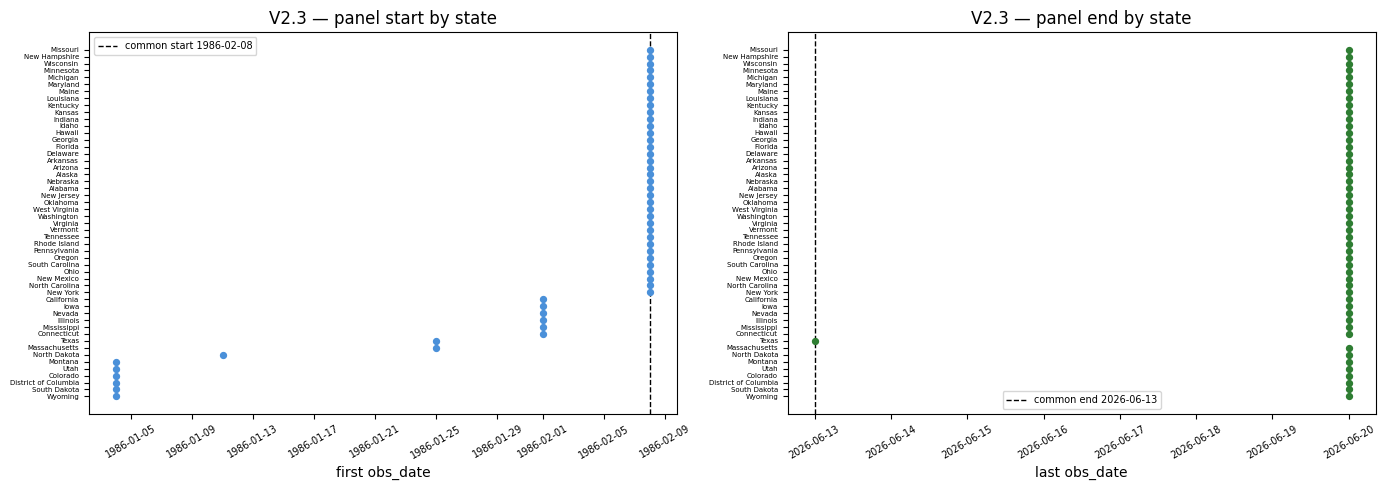

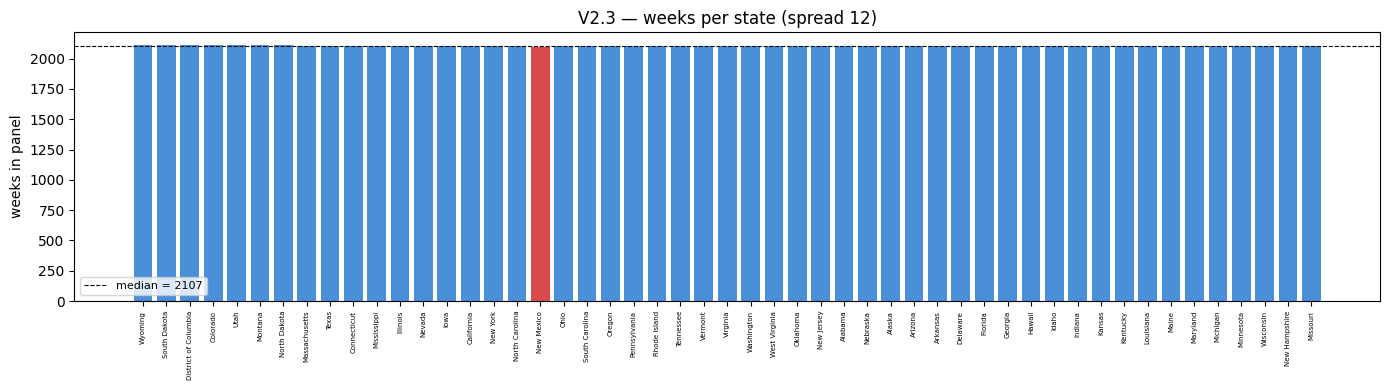

[PASS] V2.3   Panel edges aligned across states  |  start spread=5w, end spread=1w  (criterion: start<=10w, end<=1w)
       note: common balanced window: 1986-02-08 -> 2026-06-13


In [18]:
# V2.3 — do all states cover the same window? (panel start/end spread)
_edges = (cc_c.groupby("state")["obs_date"]
          .agg(first_week="min", last_week="max", n_weeks="count")
          .sort_values("first_week"))
start_spread = int((_edges["first_week"].max() - _edges["first_week"].min()).days // 7)
end_spread = int((_edges["last_week"].max() - _edges["last_week"].min()).days // 7)
common_start = _edges["first_week"].max()
common_end = _edges["last_week"].min()
common_weeks = int((common_end - common_start).days // 7) + 1

print("V2.3 — panel edges across states, revised (current) cclaims")
print(f"  (criterion: start spread <= 10w, end spread <= 1w)")
print(f"  start spread: {start_spread}w  ({_edges['first_week'].min().date()} .. {_edges['first_week'].max().date()})")
print(f"  end spread:   {end_spread}w  ({_edges['last_week'].min().date()} .. {_edges['last_week'].max().date()})")
print(f"  common balanced window: {common_start.date()} -> {common_end.date()}  ({common_weeks:,} weeks)")
print("\nV2.3 — first/last obs_date per state:")
print(_edges.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
states = _edges.index.tolist()
y = range(len(states))
axes[0].scatter(_edges["first_week"], y, c="#4a90d9", s=18, zorder=3)
axes[0].axvline(common_start, color="black", ls="--", lw=1, label=f"common start {common_start.date()}")
axes[0].set_yticks(y); axes[0].set_yticklabels(states, fontsize=5)
axes[0].set_xlabel("first obs_date"); axes[0].set_title("V2.3 — panel start by state")
axes[0].legend(fontsize=7); axes[0].tick_params(axis="x", labelrotation=30, labelsize=7)

axes[1].scatter(_edges["last_week"], y, c="#2e7d32", s=18, zorder=3)
axes[1].axvline(common_end, color="black", ls="--", lw=1, label=f"common end {common_end.date()}")
axes[1].set_yticks(y); axes[1].set_yticklabels(states, fontsize=5)
axes[1].set_xlabel("last obs_date"); axes[1].set_title("V2.3 — panel end by state")
axes[1].legend(fontsize=7); axes[1].tick_params(axis="x", labelrotation=30, labelsize=7)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
med = _edges["n_weeks"].median()
cols = ["#d94a4a" if abs(v - med) > 5 else "#4a90d9" for v in _edges["n_weeks"]]
ax.bar(range(len(states)), _edges["n_weeks"].values, color=cols, width=0.8)
ax.axhline(med, color="black", ls="--", lw=0.8, label=f"median = {med:.0f}")
ax.set_xticks(range(len(states))); ax.set_xticklabels(states, rotation=90, fontsize=5)
ax.set_ylabel("weeks in panel")
ax.set_title(f"V2.3 — weeks per state (spread {int(_edges['n_weeks'].max() - _edges['n_weeks'].min())})")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V2", "V2.3", "Panel edges aligned across states",
          "PASS" if start_spread <= 10 and end_spread <= 1 else "WARN",
          metric=f"start spread={start_spread}w, end spread={end_spread}w",
          threshold="start<=10w, end<=1w",
          note=f"common balanced window: {common_start.date()} -> {common_end.date()}")


## V3 — Point-in-time & release calendar — *information time: when the number became known*

This module validates the **information clock** — the counterpart to V2's observation clock:

| Clock | Field | Convention |
|---|---|---|
| **Observation time** — the week being *measured* | `obs_date` | DOL weeks end **Saturday** (V2.1) |
| **Information time** — when the number became *known* | `first_release_date` | DOL ETA report **Thursday ~8:30 ET** (Wed on holidays); CC first appears at obs+12d |

| Check | Question it answers |
|---|---|
| V3.1 | How far back can point-in-time be reconstructed? |
| V3.2 | Does the vintage calendar match the DOL mid-week release schedule? |
| V3.3 | Is the national first release the advance print at obs+12d? |
| V3.4 | On which weekday does FRED capture state data? |
| V3.5 | How long after the public release do state values appear? |
| V3.5b | Is the state-vs-national gap pattern stable within each era? |
| V3.6 | Could a backtest have seen state data before it was public? |
| V3.7 | Has FRED's capture timing / stored print type been stable? |
| V3.8 | Do weeks become available in order? |
| V3.9 | Does the PIT panel contain any look-ahead? |


## V3.1 — How far back can point-in-time be reconstructed?


V3.1 — point-in-time reconstruction boundary (criterion: boundary documented):
  first ALFRED vintage (any state):  2010-09-16
  last  ALFRED vintage:             2026-07-07
  obs_date span (cclaims vintage):  2010-08-28 -> 2026-06-27
  PIT as_of_date span:              2010-11-05 -> 2026-07-03
  vintage rows with obs_date BEFORE first vintage: 153  (current-only history)

V3.1 — timeline summary:
                         layer      start        end
obs_date (all cclaims vintage) 2010-08-28 2026-06-27
  first_release_date (archive) 2010-09-16 2026-07-07
                PIT as_of_date 2010-11-05 2026-07-03

V3.1 — first vintage date per state (sorted):
               state first_vintage
             Alabama    2010-09-16
            Nebraska    2010-09-16
              Nevada    2010-09-16
       New Hampshire    2010-09-16
          New Jersey    2010-09-16
          New Mexico    2010-09-16
            New York    2010-09-16
      North Carolina    2010-09-16
        North Dakota    2

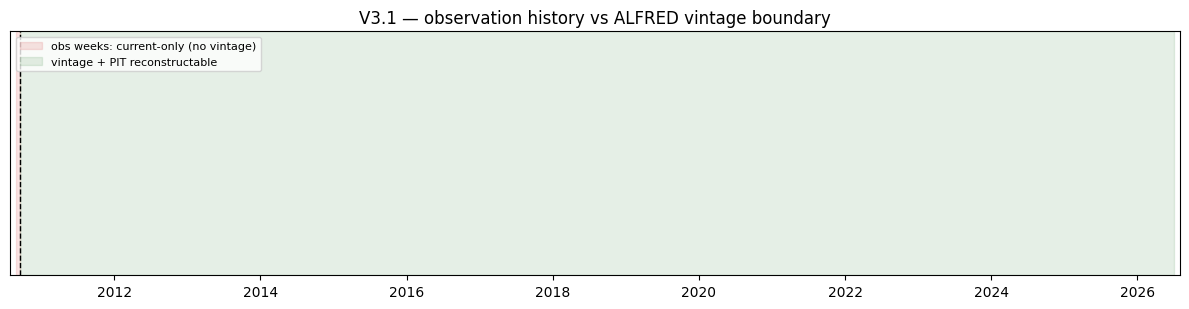

[WARN] V3.1   ALFRED vintage boundary identified  |  first vintage 2010-09-16  (criterion: documented)
       note: pre-boundary history (1986->2010-09) exists only as current values: usable for seasonality/climatology, NOT for backtesting


In [19]:
# V3.1 — ALFRED vintage boundary (pre-boundary obs exist only as current values)
vint_start = df_v["first_release_date"].min()
vint_end = df_v["first_release_date"].max()
obs_min, obs_max = df_v["obs_date"].min(), df_v["obs_date"].max()
pit_start, pit_end = pit["as_of_date"].min(), pit["as_of_date"].max()
pre_vint_obs = int((cc_v["obs_date"] < vint_start).sum())
state_first_vint = cc_v.groupby("state")["first_release_date"].min().sort_values()

print("V3.1 — point-in-time reconstruction boundary (criterion: boundary documented):")
print(f"  first ALFRED vintage (any state):  {vint_start.date()}")
print(f"  last  ALFRED vintage:             {vint_end.date()}")
print(f"  obs_date span (cclaims vintage):  {obs_min.date()} -> {obs_max.date()}")
print(f"  PIT as_of_date span:              {pit_start.date()} -> {pit_end.date()}")
print(f"  vintage rows with obs_date BEFORE first vintage: {pre_vint_obs:,}  (current-only history)")

_summary = pd.DataFrame({
    "layer": ["obs_date (all cclaims vintage)", "first_release_date (archive)", "PIT as_of_date"],
    "start": [obs_min.date(), vint_start.date(), pit_start.date()],
    "end": [obs_max.date(), vint_end.date(), pit_end.date()],
})
print("\nV3.1 — timeline summary:")
print(_summary.to_string(index=False))

print("\nV3.1 — first vintage date per state (sorted):")
print(state_first_vint.reset_index(name="first_vintage").to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axvspan(obs_min, vint_start, alpha=0.15, color="#d94a4a", label="obs weeks: current-only (no vintage)")
ax.axvspan(vint_start, pit_end, alpha=0.12, color="#2e7d32", label="vintage + PIT reconstructable")
ax.axvline(vint_start, color="black", ls="--", lw=1)
ax.set_xlim(obs_min - pd.Timedelta(days=30), pit_end + pd.Timedelta(days=30))
ax.set_yticks([])
ax.set_title("V3.1 — observation history vs ALFRED vintage boundary")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

add_check("V3", "V3.1", "ALFRED vintage boundary identified", "WARN",
          metric=f"first vintage {vint_start.date()}", threshold="documented",
          note="pre-boundary history (1986->2010-09) exists only as current values: "
               "usable for seasonality/climatology, NOT for backtesting")


## V3.2 — Does the vintage calendar match the DOL mid-week release schedule?


V3.2 — national CCNSA vintage calendar (criterion: Thu+Wed >= 99%):
  vintage dates: 867
    Wed    29  (3.3%)
    Thu   838  (96.7%)


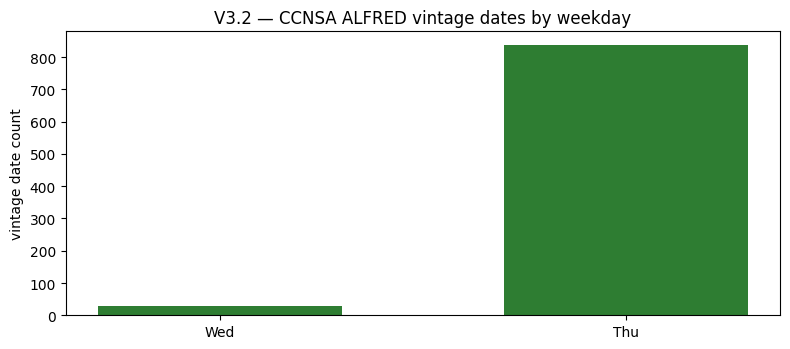

[PASS] V3.2   National CCNSA vintages land mid-week (Thu, or holiday-Wed)  |  Thu 96.7%, Wed 3.3% of 867 vintages  (criterion: Thu+Wed >= 99%)
       note: Wednesday releases are the holiday-shifted reports (Thanksgiving, Jul 4, ...)


In [20]:
# V3.2 — national CCNSA vintage dates land Thursday (or holiday Wednesday)
_WD = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
nat_wd = nat_vdates.dt.dayofweek.value_counts().sort_index()
thu_share = nat_wd.get(3, 0) / len(nat_vdates)
wed_share = nat_wd.get(2, 0) / len(nat_vdates)

print("V3.2 — national CCNSA vintage calendar (criterion: Thu+Wed >= 99%):")
print(f"  vintage dates: {len(nat_vdates):,}")
for d, n in nat_wd.items():
    print(f"    {_WD[d]:3s}  {int(n):4d}  ({n/len(nat_vdates):.1%})")

fig, ax = plt.subplots(figsize=(8, 3.6))
cols = ["#d94a4a" if d not in (2, 3) else "#2e7d32" for d in nat_wd.index]
ax.bar([_WD[d] for d in nat_wd.index], nat_wd.values, color=cols, width=0.6)
ax.set_ylabel("vintage date count")
ax.set_title("V3.2 — CCNSA ALFRED vintage dates by weekday")
plt.tight_layout(); plt.show()

add_check("V3", "V3.2", "National CCNSA vintages land mid-week (Thu, or holiday-Wed)",
          "PASS" if thu_share + wed_share >= 0.99 else "FAIL",
          metric=f"Thu {thu_share:.1%}, Wed {wed_share:.1%} of {len(nat_vdates)} vintages",
          threshold="Thu+Wed >= 99%",
          note="Wednesday releases are the holiday-shifted reports (Thanksgiving, Jul 4, ...)")


## V3.3 — Is the national first release the advance print at obs+12d?


V3.3 — national CCNSA first-release lag (criterion: median == 12d):
              count  mean  std   min   25%   50%   75%   max
pub_lag_days  877.0  12.2  2.8  11.0  12.0  12.0  12.0  61.0
  median=12d  mode=12d

V3.3 — obs weeks with lag != 12d (40):
  obs_date first_release_date  pub_lag_days
2009-11-14         2009-11-25            11
2010-10-30         2010-11-10            11
2010-11-13         2010-11-24            11
2011-11-12         2011-11-23            11
2012-11-10         2012-11-21            11
2013-06-22         2013-07-03            11
2013-11-16         2013-11-27            11
2014-07-05         2014-07-24            19
2014-11-15         2014-11-26            11
2014-12-13         2014-12-24            11
2014-12-20         2014-12-31            11
2015-11-14         2015-11-25            11
2016-11-12         2016-11-23            11
2017-02-11         2017-03-02            19
2017-11-11         2017-11-22            11
2017-12-30         2018-01-18            19

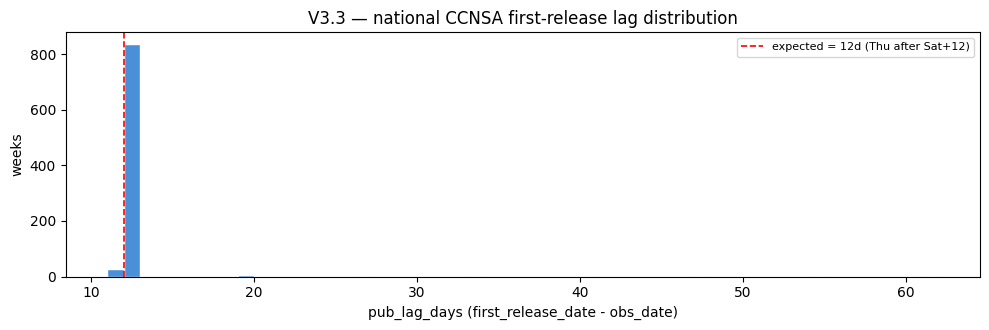

[PASS] V3.3   National CC first release = advance print (Sat + 12d = Thursday)  |  median lag 12d (min 11, max 61)  (criterion: median == 12d)
       note: CC reference week trails the report by 12 days (one week behind initial claims)


In [21]:
# V3.3 — national CC first-release lag from week-ending Saturday
_lag = nat_v["pub_lag_days"]
nat_lag_med = float(_lag.median())

print("V3.3 — national CCNSA first-release lag (criterion: median == 12d):")
print(_lag.describe().round(1).to_frame("pub_lag_days").T.to_string())
print(f"  median={nat_lag_med:.0f}d  mode={int(_lag.mode().iloc[0])}d")

_off = (_lag != 12).sum()
if _off:
    print(f"\nV3.3 — obs weeks with lag != 12d ({_off}):")
    print(nat_v.loc[_lag != 12, ["obs_date", "first_release_date", "pub_lag_days"]]
          .sort_values("obs_date").to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(_lag, bins=range(int(_lag.min()), int(_lag.max()) + 2), color="#4a90d9", edgecolor="white")
ax.axvline(12, color="red", ls="--", lw=1.2, label="expected = 12d (Thu after Sat+12)")
ax.set_xlabel("pub_lag_days (first_release_date - obs_date)")
ax.set_ylabel("weeks")
ax.set_title("V3.3 — national CCNSA first-release lag distribution")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V3", "V3.3", "National CC first release = advance print (Sat + 12d = Thursday)",
          "PASS" if nat_lag_med == 12 else "WARN",
          metric=f"median lag {nat_lag_med:.0f}d (min {_lag.min()}, max {_lag.max()})",
          threshold="median == 12d",
          note="CC reference week trails the report by 12 days (one week behind initial claims)")


## V3.4 — On which weekday does FRED capture state data?


V3.4 — state capture weekday (criterion: Thu+Fri+Wed >= 90%):
    Mon   2,082  (4.9%)
    Tue      58  (0.1%)
    Wed     561  (1.3%)
    Thu  25,296  (60.1%)
    Fri  14,127  (33.5%)


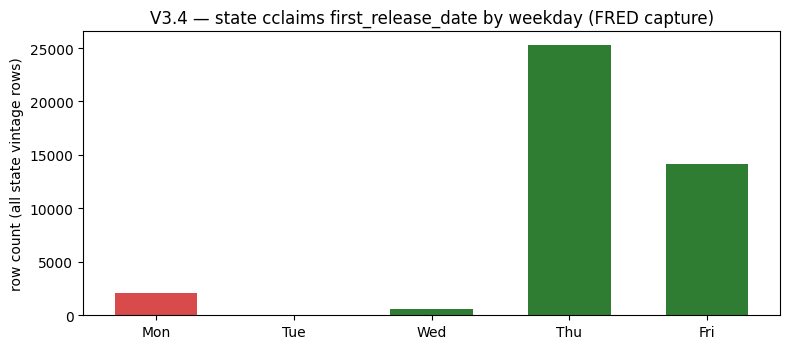

[PASS] V3.4   State captures cluster on/next-day-after release days  |  Mon 4.9%; Tue 0.1%; Wed 1.3%; Thu 60.1%; Fri 33.5%  (criterion: Thu+Fri+Wed >= 90%)
       note: Mon captures are FRED ingestion delays, not release timing — see V3.5/V3.6


In [22]:
# V3.4 — state first_release_date weekday profile (FRED capture, not DOL publication)
_WD = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
st_wd = cc_v["first_release_date"].dt.dayofweek.value_counts().sort_index()
st_wd_pct = (st_wd / st_wd.sum()).sort_index()
thu_fri_wed = st_wd_pct.get(3, 0) + st_wd_pct.get(4, 0) + st_wd_pct.get(2, 0)

print("V3.4 — state capture weekday (criterion: Thu+Fri+Wed >= 90%):")
for d, n in st_wd.items():
    print(f"    {_WD[d]:3s}  {int(n):6,}  ({st_wd_pct[d]:.1%})")

fig, ax = plt.subplots(figsize=(8, 3.6))
cols = ["#2e7d32" if d in (2, 3, 4) else "#d94a4a" for d in st_wd.index]
ax.bar([_WD[d] for d in st_wd.index], st_wd.values, color=cols, width=0.6)
ax.set_ylabel("row count (all state vintage rows)")
ax.set_title("V3.4 — state cclaims first_release_date by weekday (FRED capture)")
plt.tight_layout(); plt.show()

add_check("V3", "V3.4", "State captures cluster on/next-day-after release days",
          "PASS" if thu_fri_wed >= 0.90 else "WARN",
          metric="; ".join(f"{_WD[k]} {st_wd_pct[k]:.1%}" for k in st_wd_pct.index),
          threshold="Thu+Fri+Wed >= 90%",
          note="Mon captures are FRED ingestion delays, not release timing — see V3.5/V3.6")


## V3.5 — How long after the public release do state values appear?


V3.5 — state capture vs national release (criterion: >= 90% in 0-2d OR 6-8d windows):
  within 0-2d of national release: 32.5%
  at +6-8d (next report):          61.1%

V3.5 — gap_days distribution:
            count  mean   std   min  25%  50%  75%   max
gap_days  42124.0  4.67  4.27 -48.0  1.0  7.0  7.0  14.0

V3.5 — examples (CA / TX / NY):

  PRE-2020: obs week 2015-03-07 | national release 2015-03-19 (Thursday)
    California  2015-03-26  gap=+7d
    New York    2015-03-26  gap=+7d
    Texas       2015-03-26  gap=+7d

  POST-2020: obs week 2023-03-04 | national release 2023-03-16 (Thursday)
    California  2023-03-17  gap=+1d
    New York    2023-03-17  gap=+1d
    Texas       2023-03-17  gap=+1d


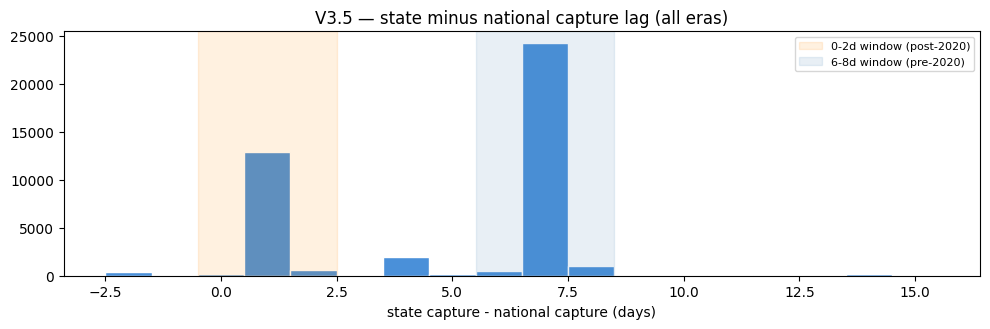

[PASS] V3.5   State first release vs national release date, same obs week  |  32.5% within 0-2d; 61.1% at +6-8d (next report)  (criterion: >= 90% in one of the two report windows)
       note: measures FRED/ALFRED CAPTURE order, not DOL publication order — states archived later by FRED


In [23]:
# V3.5 — state vs national ALFRED capture alignment (same obs week)
nat_rel = nat_v.set_index("obs_date")["first_release_date"]
al = cc_v[["state", "obs_date", "first_release_date", "pub_lag_days"]].copy()
al["nat_release"] = al["obs_date"].map(nat_rel)
al = al.dropna(subset=["nat_release"])
al["gap_days"] = (al["first_release_date"] - al["nat_release"]).dt.days

same_report = al["gap_days"].between(0, 2).mean()
next_report = al["gap_days"].between(6, 8).mean()

print("V3.5 — state capture vs national release (criterion: >= 90% in 0-2d OR 6-8d windows):")
print(f"  within 0-2d of national release: {same_report:.1%}")
print(f"  at +6-8d (next report):          {next_report:.1%}")
print(f"\nV3.5 — gap_days distribution:")
print(al["gap_days"].describe().round(2).to_frame().T.to_string())

print("\nV3.5 — examples (CA / TX / NY):")
for label, week in [("PRE-2020", pd.Timestamp("2015-03-07")), ("POST-2020", pd.Timestamp("2023-03-04"))]:
    sub = al[(al["obs_date"] == week) & al["state"].isin(["California", "Texas", "New York"])]
    if sub.empty:
        continue
    nr = sub["nat_release"].iloc[0]
    print(f"\n  {label}: obs week {week.date()} | national release {nr.date()} ({nr.day_name()})")
    for _, r in sub.sort_values("state").iterrows():
        print(f"    {r['state']:<11s} {r['first_release_date'].date()}  gap={r['gap_days']:+.0f}d")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(al["gap_days"].clip(-2, 15), bins=np.arange(-2.5, 16.5, 1), color="#4a90d9", edgecolor="white")
ax.axvspan(-0.5, 2.5, color="darkorange", alpha=0.12, label="0-2d window (post-2020)")
ax.axvspan(5.5, 8.5, color="steelblue", alpha=0.12, label="6-8d window (pre-2020)")
ax.set_xlabel("state capture - national capture (days)")
ax.set_title("V3.5 — state minus national capture lag (all eras)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V3", "V3.5", "State first release vs national release date, same obs week",
          "PASS" if same_report + next_report >= 0.90 else "WARN",
          metric=f"{same_report:.1%} within 0-2d; {next_report:.1%} at +6-8d (next report)",
          threshold=">= 90% in one of the two report windows",
          note="measures FRED/ALFRED CAPTURE order, not DOL publication order — states archived later by FRED")


## V3.5b — Is the state-vs-national gap pattern stable within each era?


V3.5b — gap pattern by era (criterion: >= 95% in-window per era):
  regime switch ~2020-07-10
  pre-2020  in-window (+6-8d): 97.8%
  post-2020 in-window (+0-2d): 83.3%
  post-2020 Monday slip (+3-5d): 13.0%

V3.5b — in-window share and median gap by release year:
                    share_in_window  median_gap_d  rows
first_release_date                                     
2010                          1.000           7.0   816
2011                          0.980           7.0  2652
2012                          1.000           7.0  2652
2013                          1.000           7.0  2652
2014                          0.979           7.0  2703
2015                          0.980           7.0  2652
2016                          1.000           7.0  2652
2017                          0.981           7.0  2652
2018                          0.962           7.0  2652
2019                          1.000           7.0  2652
2020                          0.845           4.0  2702
2021    

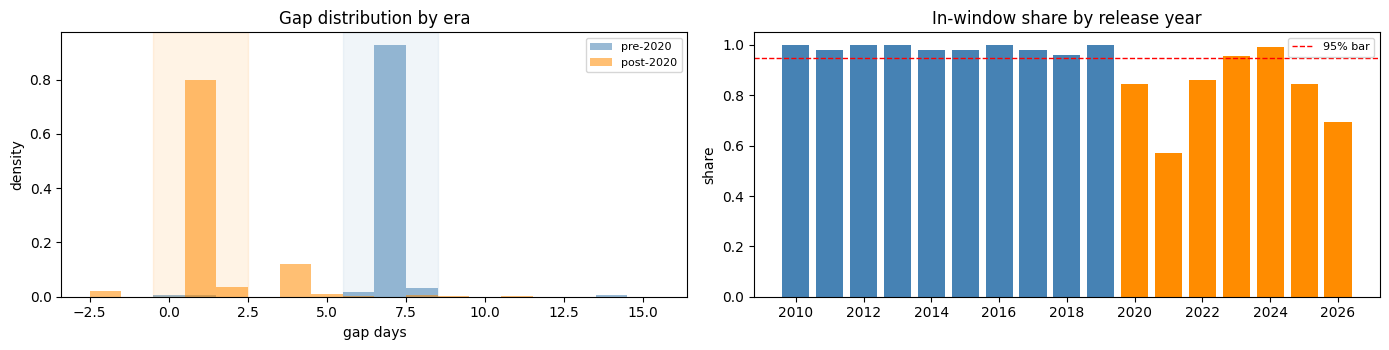

[WARN] V3.5b  Era gap pattern consistency (is +7d / +1d stable within each era?)  |  pre-2020: 97.8% at +6-8d; post-2020: 83.3% at +0-2d (+13.0% slip to +3-5d = Monday ingestion)  (criterion: >= 95% in-window per era)
       note: 2021 transition year is chaotic; negative gaps = late NATIONAL archive (V3.6), not early states


In [24]:
# V3.5b — era consistency of the state-national capture gap
lag_roll = (cc_v.sort_values("first_release_date")
            .set_index("first_release_date")["pub_lag_days"].rolling("56D").median())
switch_est = lag_roll[lag_roll < 16].index.min()
al["era"] = np.where(al["first_release_date"] >= switch_est, "post-2020", "pre-2020")
al["in_window"] = (((al["era"] == "pre-2020") & al["gap_days"].between(6, 8)) |
                   ((al["era"] == "post-2020") & al["gap_days"].between(0, 2)))
share_pre = al.loc[al["era"] == "pre-2020", "in_window"].mean()
share_post = al.loc[al["era"] == "post-2020", "in_window"].mean()
post = al[al["era"] == "post-2020"]
mon_slip = post["gap_days"].between(3, 5).mean()

print("V3.5b — gap pattern by era (criterion: >= 95% in-window per era):")
print(f"  regime switch ~{switch_est.date() if pd.notna(switch_est) else 'n/a'}")
print(f"  pre-2020  in-window (+6-8d): {share_pre:.1%}")
print(f"  post-2020 in-window (+0-2d): {share_post:.1%}")
print(f"  post-2020 Monday slip (+3-5d): {mon_slip:.1%}")

yr_tab = al.groupby(al["first_release_date"].dt.year).agg(
    share_in_window=("in_window", "mean"), median_gap_d=("gap_days", "median"), rows=("gap_days", "size"))
print("\nV3.5b — in-window share and median gap by release year:")
print(yr_tab.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
bins = np.arange(-2.5, 16.5, 1)
for era, colr in [("pre-2020", "steelblue"), ("post-2020", "darkorange")]:
    axes[0].hist(al.loc[al["era"] == era, "gap_days"].clip(-2, 15), bins=bins,
                 alpha=0.55, color=colr, label=era, density=True)
axes[0].axvspan(5.5, 8.5, color="steelblue", alpha=0.08)
axes[0].axvspan(-0.5, 2.5, color="darkorange", alpha=0.10)
axes[0].set(title="Gap distribution by era", xlabel="gap days", ylabel="density")
axes[0].legend(fontsize=8)

yrs = yr_tab.index.astype(int)
axes[1].bar(yrs, yr_tab["share_in_window"],
            color=["steelblue" if y < switch_est.year else "darkorange" for y in yrs])
axes[1].axhline(0.95, color="red", ls="--", lw=1, label="95% bar")
axes[1].set(title="In-window share by release year", ylabel="share", ylim=(0, 1.05))
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V3", "V3.5b", "Era gap pattern consistency (is +7d / +1d stable within each era?)",
          "PASS" if share_pre >= 0.95 and share_post >= 0.95 else "WARN",
          metric=f"pre-2020: {share_pre:.1%} at +6-8d; post-2020: {share_post:.1%} at +0-2d "
                 f"(+{mon_slip:.1%} slip to +3-5d = Monday ingestion)",
          threshold=">= 95% in-window per era",
          note="2021 transition year is chaotic; negative gaps = late NATIONAL archive (V3.6), not early states")


## V3.6 — Could a backtest have seen state data before it was public?


V3.6 — leak check (criterion: min state pub_lag >= 12d):
  min state pub_lag_days: 13d
  rows with pub_lag < 12: 0
  naive 'state before national' flags: 357 rows on 7 weeks (ALFRED artifact)

V3.6 — rows at minimum lag:
  state   obs_date first_release_date  pub_lag_days
Alabama 2020-05-30         2020-06-12            13
Alabama 2020-06-06         2020-06-19            13
Alabama 2020-06-13         2020-06-26            13
Alabama 2020-06-20         2020-07-03            13
Alabama 2020-06-27         2020-07-10            13
Alabama 2020-07-04         2020-07-17            13
Alabama 2020-07-11         2020-07-24            13
Alabama 2020-07-18         2020-07-31            13
Alabama 2020-07-25         2020-08-07            13
Alabama 2020-08-01         2020-08-14            13


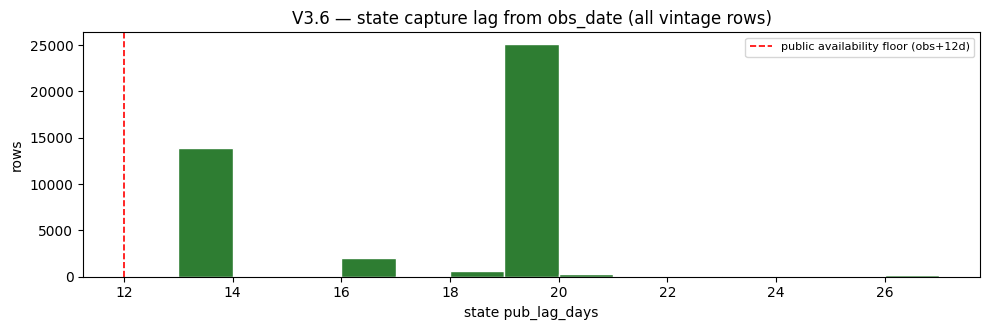


V3.6 — false-leak example: obs week 2025-09-20 — national archived late (obs+61d):
   Alabama         2025-10-03 = obs+13d (gap vs national -48d)
   Alaska          2025-10-03 = obs+13d (gap vs national -48d)
   Arkansas        2025-10-03 = obs+13d (gap vs national -48d)
[PASS] V3.6   No state value available before its DOL report (leak check)  |  min state pub lag 13d across all 42,124 vintage rows  (criterion: min lag >= 12d)
       note: naive state<national check fires 357 false alarms on 7 weeks — late NATIONAL archive, not early state data


In [25]:
# V3.6 — leak check: state pub_lag_days must be >= 12 (first public report at obs+12d)
min_state_lag = int(cc_v["pub_lag_days"].min())
neg_vs_nat = al[al["gap_days"] < 0]
late_nat_weeks = neg_vs_nat["obs_date"].nunique()

print("V3.6 — leak check (criterion: min state pub_lag >= 12d):")
print(f"  min state pub_lag_days: {min_state_lag}d")
print(f"  rows with pub_lag < 12: {int((cc_v['pub_lag_days'] < 12).sum())}")
print(f"  naive 'state before national' flags: {len(neg_vs_nat)} rows on {late_nat_weeks} weeks (ALFRED artifact)")

_low = cc_v[cc_v["pub_lag_days"] <= cc_v["pub_lag_days"].min() + 1]
print("\nV3.6 — rows at minimum lag:")
print(_low[["state", "obs_date", "first_release_date", "pub_lag_days"]]
      .sort_values(["pub_lag_days", "state"]).head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(cc_v["pub_lag_days"], bins=range(12, 28), color="#2e7d32", edgecolor="white")
ax.axvline(12, color="red", ls="--", lw=1.2, label="public availability floor (obs+12d)")
ax.set_xlabel("state pub_lag_days")
ax.set_ylabel("rows")
ax.set_title("V3.6 — state capture lag from obs_date (all vintage rows)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

if len(neg_vs_nat):
    wk = neg_vs_nat.loc[neg_vs_nat["gap_days"].idxmin(), "obs_date"]
    nl = (nat_rel[wk] - wk).days
    print(f"\nV3.6 — false-leak example: obs week {wk.date()} — national archived late (obs+{nl}d):")
    for _, r in al[al["obs_date"] == wk].nsmallest(3, "first_release_date").iterrows():
        print(f"   {r['state']:<15s} {r['first_release_date'].date()} = obs+{r['pub_lag_days']:.0f}d "
              f"(gap vs national {r['gap_days']:+.0f}d)")

add_check("V3", "V3.6", "No state value available before its DOL report (leak check)",
          "PASS" if min_state_lag >= 12 else "FAIL",
          metric=f"min state pub lag {min_state_lag}d across all {len(cc_v):,} vintage rows",
          threshold="min lag >= 12d",
          note=f"naive state<national check fires {len(neg_vs_nat)} false alarms on {late_nat_weeks} weeks — "
               "late NATIONAL archive, not early state data")


## V3.7 — Has FRED's capture timing / stored print type been stable?


V3.7 — capture-lag regime (criterion: stable median lag — structural break documented as WARN):
  switch ~2020-07-10
  pre-switch  median pub_lag: 19d  (n=26,163)  — REVISED print era
  post-switch median pub_lag: 13d  (n=15,961)  — ADVANCE print era

V3.7 — era summary:
                  era  median_lag_d  rows
 pre-switch (revised)          19.0 26163
post-switch (advance)          13.0 15961


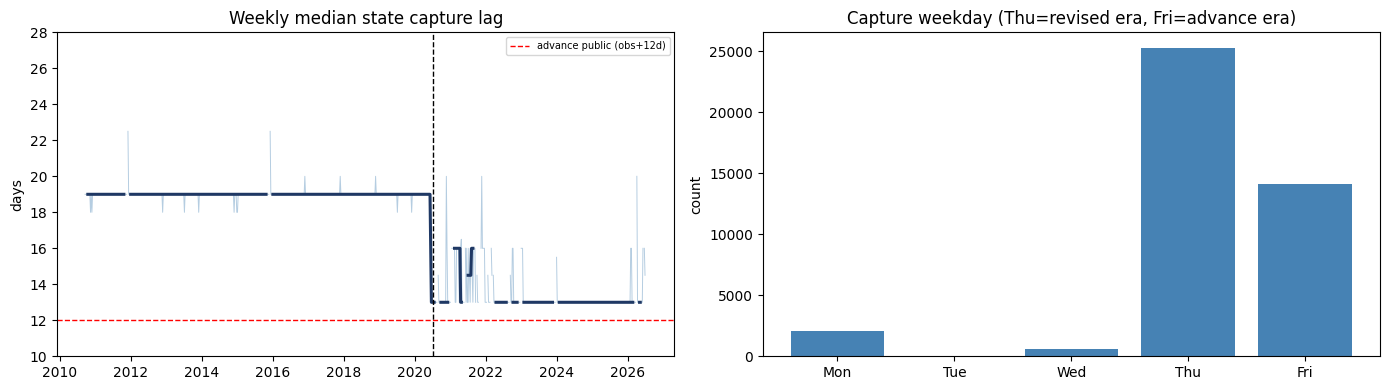

[WARN] V3.7   Capture-lag regime stability  |  switch ~2020-07-10: median 19d -> 13d  (criterion: stable median lag across sample)
       note: pre-switch stores REVISED print (captured ~Sat+19d); post-switch ADVANCE print (Sat+13d)


In [26]:
# V3.7 — capture-lag regime shift (~19d revised era -> ~13d advance era, Jul 2020)
_WD = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
lag_ts = (cc_v.sort_values("first_release_date")
          .set_index("first_release_date")["pub_lag_days"].rolling("56D").median())
switch_candidates = lag_ts[lag_ts < 16]
switch_date = switch_candidates.index.min() if len(switch_candidates) else None
era_old = cc_v[cc_v["first_release_date"] < switch_date] if switch_date is not None else cc_v.iloc[0:0]
era_new = cc_v[cc_v["first_release_date"] >= switch_date] if switch_date is not None else cc_v
med_old = float(era_old["pub_lag_days"].median()) if len(era_old) else float("nan")
med_new = float(era_new["pub_lag_days"].median()) if len(era_new) else float("nan")
regime_shift = switch_date is not None and abs(med_old - med_new) >= 3

print("V3.7 — capture-lag regime (criterion: stable median lag — structural break documented as WARN):")
print(f"  switch ~{switch_date.date() if switch_date is not None else 'n/a'}")
print(f"  pre-switch  median pub_lag: {med_old:.0f}d  (n={len(era_old):,})  — REVISED print era")
print(f"  post-switch median pub_lag: {med_new:.0f}d  (n={len(era_new):,})  — ADVANCE print era")

_era_tbl = pd.DataFrame({
    "era": ["pre-switch (revised)", "post-switch (advance)"],
    "median_lag_d": [med_old, med_new],
    "rows": [len(era_old), len(era_new)],
})
print("\nV3.7 — era summary:")
print(_era_tbl.to_string(index=False))

lag_weekly = (cc_v.set_index("first_release_date")["pub_lag_days"]
              .sort_index().resample("W").median())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(lag_weekly.index, lag_weekly.values, lw=0.7, color="steelblue", alpha=0.4)
axes[0].plot(lag_weekly.index, lag_weekly.rolling(9, center=True).median(), lw=2.2, color="#1f3864")
axes[0].axhline(12, color="red", ls="--", lw=1, label="advance public (obs+12d)")
if switch_date is not None:
    axes[0].axvline(switch_date, color="black", ls="--", lw=1)
axes[0].set(title="Weekly median state capture lag", ylabel="days", ylim=(10, 28))
axes[0].legend(fontsize=7)

wd_all = cc_v["first_release_date"].dt.dayofweek.value_counts().sort_index()
axes[1].bar([_WD[k] for k in wd_all.index], wd_all.values, color="steelblue")
axes[1].set(title="Capture weekday (Thu=revised era, Fri=advance era)", ylabel="count")
plt.tight_layout(); plt.show()

add_check("V3", "V3.7", "Capture-lag regime stability",
          "WARN" if regime_shift else "PASS",
          metric=(f"switch ~{switch_date.date() if switch_date is not None else 'n/a'}: "
                  f"median {med_old:.0f}d -> {med_new:.0f}d"),
          threshold="stable median lag across sample",
          note="pre-switch stores REVISED print (captured ~Sat+19d); post-switch ADVANCE print (Sat+13d)")


## V3.8 — Do weeks become available in order?


V3.8 — release-order monotonicity (criterion: 0 inversions): 0
  (none — every state's release dates are non-decreasing in obs order)

V3.8 — max backward release step per state (top 10):
         state  max_backward_days
       Alabama                  0
  Pennsylvania                  0
        Nevada                  0
 New Hampshire                  0
    New Jersey                  0
    New Mexico                  0
      New York                  0
North Carolina                  0
  North Dakota                  0
          Ohio                  0


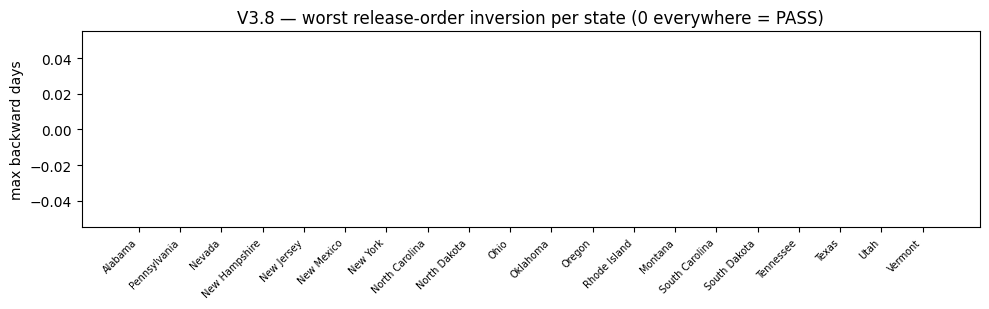

[PASS] V3.8   Release dates weakly increasing in obs order (per state)  |  0 inversions  (criterion: == 0)
       note: inversion = later obs week visible before earlier one — PIT builder uses cummax frontier


In [27]:
# V3.8 — release dates weakly increase in obs_date order (availability frontier)
_inv_rows = []
for state, g in cc_v.groupby("state"):
    g = g.sort_values("obs_date")
    rel = g["first_release_date"].values
    obs = g["obs_date"].values
    for i in range(1, len(rel)):
        if rel[i] < rel[i - 1]:
            _inv_rows.append({
                "state": state,
                "obs_date": obs[i],
                "release": rel[i],
                "prior_obs": obs[i - 1],
                "prior_release": rel[i - 1],
            })
inversions = len(_inv_rows)
inv_df = pd.DataFrame(_inv_rows)

print(f"V3.8 — release-order monotonicity (criterion: 0 inversions): {inversions}")
if inversions:
    print(inv_df.to_string(index=False))
else:
    print("  (none — every state's release dates are non-decreasing in obs order)")

# per-state max backward step (should be 0)
_max_back = []
for state, g in cc_v.groupby("state"):
    rel = g.sort_values("obs_date")["first_release_date"]
    back = (rel.shift(1) - rel).dt.days
    _max_back.append({"state": state, "max_backward_days": int(back.max()) if back.notna().any() else 0})
_back_tbl = pd.DataFrame(_max_back).sort_values("max_backward_days", ascending=False)
print("\nV3.8 — max backward release step per state (top 10):")
print(_back_tbl.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(range(min(20, len(_back_tbl))), _back_tbl["max_backward_days"].head(20).values, color="#2e7d32")
ax.set_xticks(range(min(20, len(_back_tbl))))
ax.set_xticklabels(_back_tbl["state"].head(20), rotation=45, ha="right", fontsize=7)
ax.set_ylabel("max backward days")
ax.set_title("V3.8 — worst release-order inversion per state (0 everywhere = PASS)")
plt.tight_layout(); plt.show()

add_check("V3", "V3.8", "Release dates weakly increasing in obs order (per state)",
          "PASS" if inversions == 0 else "WARN",
          metric=f"{inversions} inversions", threshold="== 0",
          note="inversion = later obs week visible before earlier one — PIT builder uses cummax frontier")


## V3.9 — Does the PIT panel contain any look-ahead?


V3.9 — PIT look-ahead guard (criterion: 0 violations, 0 unmatched):
  PIT rows: 41,718
  violations (release > as_of): 0
  unmatched keys: 0
  staleness days (as_of - latest_obs release): median=1  max=14
  (no look-ahead violations)


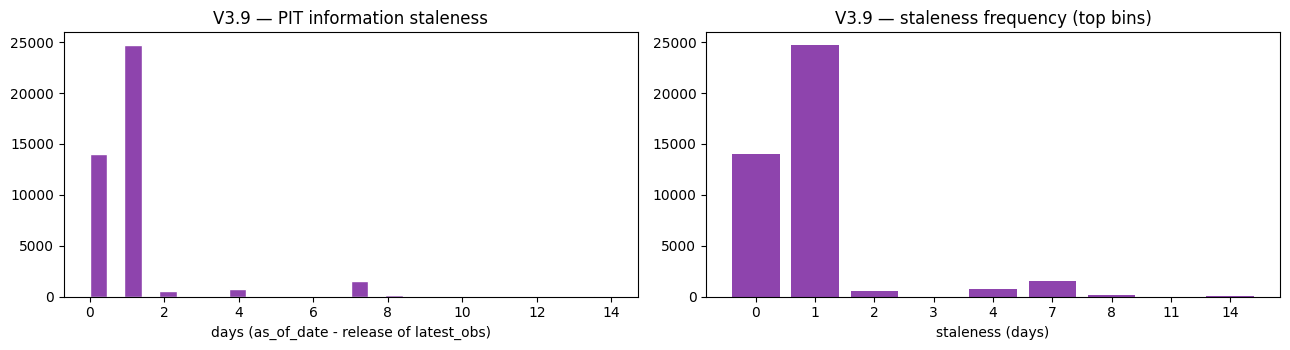

[PASS] V3.9   PIT panel look-ahead guard (cclaims_latest_obs released <= as_of_date)  |  0 violations, 0 unmatched keys of 41,718 rows  (criterion: == 0)


In [28]:
# V3.9 — PIT look-ahead guard: cclaims_latest_obs must be released on or before as_of_date
rel_lookup = cc_v.set_index(["state", "obs_date"])["first_release_date"]
pit_keys = pd.MultiIndex.from_arrays([pit["state"], pit["cclaims_latest_obs"]])
pit_rel = rel_lookup.reindex(pit_keys).values
pit_rel_ts = pd.to_datetime(pit_rel)
viol_mask = pit_rel_ts > pit["as_of_date"].values
violations = int(viol_mask.sum())
unmatched = int(pd.isna(pit_rel).sum())
staleness = (pit["as_of_date"] - pit_rel_ts).dt.days

print("V3.9 — PIT look-ahead guard (criterion: 0 violations, 0 unmatched):")
print(f"  PIT rows: {len(pit):,}")
print(f"  violations (release > as_of): {violations}")
print(f"  unmatched keys: {unmatched}")
print(f"  staleness days (as_of - latest_obs release): median={staleness.median():.0f}  "
      f"max={staleness.max():.0f}")

if violations:
    _viol = pit.loc[viol_mask, ["as_of_date", "state", "cclaims_latest_obs"]].copy()
    _viol["release_date"] = pit_rel_ts[viol_mask]
    print("\nV3.9 — violation rows:")
    print(_viol.sort_values(["as_of_date", "state"]).to_string(index=False))
else:
    print("  (no look-ahead violations)")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(staleness.dropna(), bins=30, color="#8e44ad", edgecolor="white")
axes[0].set_xlabel("days (as_of_date - release of latest_obs)")
axes[0].set_title("V3.9 — PIT information staleness")

_axes1_data = staleness.value_counts().sort_index().head(15)
axes[1].bar(_axes1_data.index.astype(str), _axes1_data.values, color="#8e44ad")
axes[1].set_xlabel("staleness (days)")
axes[1].set_title("V3.9 — staleness frequency (top bins)")
plt.tight_layout(); plt.show()

add_check("V3", "V3.9", "PIT panel look-ahead guard (cclaims_latest_obs released <= as_of_date)",
          "PASS" if violations == 0 and unmatched == 0 else "FAIL",
          metric=f"{violations} violations, {unmatched} unmatched keys of {len(pit):,} rows",
          threshold="== 0")


## V4 — Revision behavior: first release and after

| Check | Question it answers |
|---|---|
| V4.1 | How often does a first print get revised at all (endpoint: first vs current)? |
| V4.1b | Where are the revisions concentrated (states / periods)? |
| V4.2 | Do values change mid-life and net out — invisible to the endpoint check? |
| V4.3 | How different is an *advance print* from its *revised print* — does the V3.7 era mixing matter? |

Three layers: (1) **first release vs current** across all states — spoiler: **not** negligible (~3% of obs), heavily concentrated in a few chronic-reviser states and 2020–22; (2) **full vintage trajectory** (`output_type=2`) for sample states incl. Hawaii, the worst chronic reviser; (3) **national calibration**: the national series archives *both* the advance and the revised print of every week, so we use it to measure how different the two prints typically are — which bounds the inconsistency introduced by the V3.7 capture-regime change.

*(The TX 2024-06 forensic case — a data error discovered by V4.1 — is presented as V5.4 with the other anomalies.)*

## V4.1 — How often does a first print get revised at all (endpoint: first vs current)?


In [29]:
# V4.1 — endpoint revisions: first release vs current, all states
rev = cc_v.merge(cc_c[["state", "obs_date", "value_current"]], on=["state", "obs_date"], how="inner")
rev["revision"] = rev["value_current"] - rev["value_first_release"]
rev["revision_pct"] = rev["revision"] / rev["value_first_release"] * 100
exceptions = rev[rev["revision"] != 0].copy()
share_revised = len(exceptions) / len(rev)

print("V4.1 — endpoint revision rate (criterion: PASS < 0.5%, WARN < 5%):")
print(f"  rows compared: {len(rev):,}")
print(f"  revised:       {len(exceptions):,}  ({share_revised:.2%})")
print(f"  unchanged:     {len(rev) - len(exceptions):,}")

if len(exceptions):
    print(f"\n  |revision_pct| summary:")
    print(exceptions["revision_pct"].abs().describe().round(2).to_string())

add_check("V4", "V4.1", "Endpoint revision rate (first release vs current)",
          "PASS" if share_revised < 0.005 else ("WARN" if share_revised < 0.05 else "FAIL"),
          metric=f"{len(exceptions)} of {len(rev):,} obs revised ({share_revised:.2%})",
          threshold="PASS < 0.5%, WARN < 5%",
          note="NOT the near-zero rate a small-sample probe suggests: revisions are real but concentrated "
               "— see the by-state and by-year breakdowns; full exception list feeds V9.4")


V4.1 — endpoint revision rate (criterion: PASS < 0.5%, WARN < 5%):
  rows compared: 42,124
  revised:       1,403  (3.33%)
  unchanged:     40,721

  |revision_pct| summary:
count     1403.00
mean        17.46
std        365.33
min          0.00
25%          0.10
50%          0.31
75%          3.69
max      13504.55
[WARN] V4.1   Endpoint revision rate (first release vs current)  |  1403 of 42,124 obs revised (3.33%)  (criterion: PASS < 0.5%, WARN < 5%)
       note: NOT the near-zero rate a small-sample probe suggests: revisions are real but concentrated — see the by-state and by-year breakdowns; full exception list feeds V9.4


## V4.1b — Where are the revisions concentrated (states / periods)?


V4.1b — revision concentration (criterion: documented):
  top-4 states share: 56% of 1,403 exceptions

V4.1b — exceptions by state (top 15):
                n  med_abs_pct
state                         
Hawaii        404     0.211082
Pennsylvania  168     0.083590
New Mexico    111     2.980070
Maryland      104     0.056290
Kansas         65    11.711415
Nebraska       62     1.162769
Colorado       60    20.610081
Kentucky       50     0.293079
Vermont        45     0.074766
Ohio           28     4.785400
Florida        23    11.228257
Wyoming        22     3.669081
Virginia       20     0.865098
Louisiana      20     9.644110
Alabama        20     4.218026

V4.1b — exceptions by obs year:
obs_date
2010     27
2011      9
2012     18
2013     70
2014     37
2015     54
2016     28
2017     27
2018     60
2019     93
2020    298
2021    150
2022    162
2023    117
2024    121
2025     99
2026     33

V4.1b — top 30 largest exceptions by |%|:
               state abbr   obs_date first_

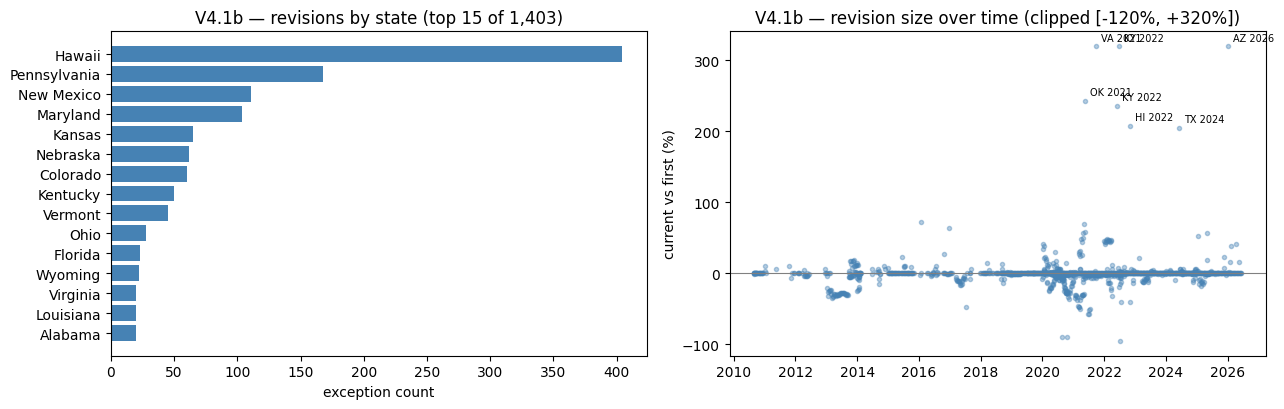

In [30]:
# V4.1b — concentration: chronic-reviser states and the pandemic-correction window
by_state = (exceptions.groupby("state")
            .agg(n=("obs_date", "count"), med_abs_pct=("revision_pct", lambda s: s.abs().median()))
            .sort_values("n", ascending=False))
top_share = by_state["n"].head(4).sum() / len(exceptions)

print("V4.1b — revision concentration (criterion: documented):")
print(f"  top-4 states share: {top_share:.0%} of {len(exceptions):,} exceptions")
print("\nV4.1b — exceptions by state (top 15):")
print(by_state.head(15).to_string())

print("\nV4.1b — exceptions by obs year:")
print(exceptions.groupby(exceptions["obs_date"].dt.year).size().to_string())

print("\nV4.1b — top 30 largest exceptions by |%|:")
exc_view = exceptions[["state", "abbr", "obs_date", "first_release_date",
                       "value_first_release", "value_current", "revision_pct"]].copy()
exc_view["obs_date"] = exc_view["obs_date"].dt.strftime("%Y-%m-%d")
exc_view["first_release_date"] = exc_view["first_release_date"].dt.strftime("%Y-%m-%d")
print(exc_view.sort_values("revision_pct", key=abs, ascending=False).head(30).to_string(index=False))
exceptions.to_csv("claims_revision_exceptions.csv", index=False)
print("\nFull exception list saved to claims_revision_exceptions.csv")

add_check("V4", "V4.1b", "Revisions concentrated (chronic states + 2020-22 window)",
          "WARN",
          metric=f"top-4 states = {top_share:.0%} of exceptions: "
                 + ", ".join(f"{s} n={int(r.n)} (med |{r.med_abs_pct:.1f}%|)"
                             for s, r in by_state.head(4).iterrows()),
          threshold="documented",
          note="chronic revisers publish systematically preliminary first prints — consider state-specific "
               "noise handling or a revised_later flag feature; 2020-22 corrections are pandemic-era admin fixes")

top15 = by_state.head(15)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].barh(list(top15.index)[::-1], list(top15["n"])[::-1], color="steelblue")
axes[0].set_xlabel("exception count")
axes[0].set_title(f"V4.1b — revisions by state (top 15 of {len(exceptions):,})")

clipped = exceptions["revision_pct"].clip(-120, 320)
axes[1].scatter(exceptions["obs_date"], clipped, s=9, alpha=0.4, color="steelblue")
axes[1].axhline(0, color="gray", lw=0.8)
big = exceptions[exceptions["revision_pct"].abs() > 150]
for _, r in big.iterrows():
    axes[1].annotate(f"{r['abbr']} {r['obs_date'].year}",
                     (r["obs_date"], min(r["revision_pct"], 320)),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].set(title="V4.1b — revision size over time (clipped [-120%, +320%])",
            ylabel="current vs first (%)")
plt.tight_layout(); plt.show()


## V4.2 — Do values change mid-life and net out — invisible to the endpoint check?


V4.2 — intermediate revisions via full vintage trajectory (criterion: core < 0.5%):
  California: 2108 obs x 820 vintages; multi-valued: 5 (max 2 values)
  Texas: 2108 obs x 819 vintages; multi-valued: 4 (max 2 values)
  New York: 2107 obs x 822 vintages; multi-valued: 14 (max 2 values)
  Florida: 2107 obs x 822 vintages; multi-valued: 24 (max 3 values)
  Michigan: 2126 obs x 821 vintages; multi-valued: 2 (max 2 values)
  Hawaii: 2152 obs x 831 vintages; multi-valued: 405 (max 5 values)
[PASS] V4.2   Intermediate revisions bounded (full trajectory, 5 core states)  |  core states: 49 multi-valued obs of 10,556 (0.46%); Hawaii: 405 of 2152 (up to 5 values per obs)  (criterion: core < 0.5% (chronic states reported separately))
       note: core states are (near-)single-valued across all vintages, so V4.1's endpoint join captures their revision behavior; Hawaii revises repeatedly (up to 5 values per week) — its first prints are genuinely preliminary


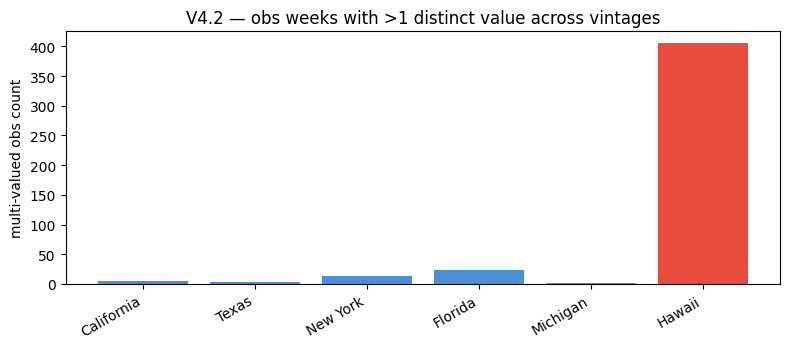

In [31]:
# V4.2 — full vintage trajectories (output_type=2): core sample + Hawaii (worst chronic reviser)
CORE = {"CACCLAIMS": "California", "TXCCLAIMS": "Texas", "NYCCLAIMS": "New York",
        "FLCCLAIMS": "Florida", "MICCLAIMS": "Michigan"}
CHRONIC = {"HICCLAIMS": "Hawaii"}

traj_summary = {}
for sid, state in {**CORE, **CHRONIC}.items():
    d = fred_get({"series_id": sid, "realtime_start": "1776-07-04", "realtime_end": "9999-12-31",
                  "output_type": 2, "limit": 100000})
    t = pd.DataFrame(d["observations"])
    vcols = [c for c in t.columns if c.startswith(sid)]
    vals = t[vcols].replace(".", np.nan).astype(float)
    n_distinct = vals.apply(lambda r: r.dropna().nunique(), axis=1)
    traj_summary[state] = {"obs": len(t), "vintages": len(vcols),
                           "multi": int((n_distinct > 1).sum()),
                           "max_values": int(n_distinct.max())}
    time.sleep(0.5)

core_multi = sum(traj_summary[s]["multi"] for s in CORE.values())
core_obs   = sum(traj_summary[s]["obs"] for s in CORE.values())

print("V4.2 — intermediate revisions via full vintage trajectory (criterion: core < 0.5%):")
for state, s in traj_summary.items():
    print(f"  {state}: {s['obs']} obs x {s['vintages']} vintages; "
          f"multi-valued: {s['multi']} (max {s['max_values']} values)")

add_check("V4", "V4.2", "Intermediate revisions bounded (full trajectory, 5 core states)",
          "PASS" if core_multi / core_obs < 0.005 else "WARN",
          metric=f"core states: {core_multi} multi-valued obs of {core_obs:,} ({core_multi/core_obs:.2%}); "
                 f"Hawaii: {traj_summary['Hawaii']['multi']} of {traj_summary['Hawaii']['obs']} "
                 f"(up to {traj_summary['Hawaii']['max_values']} values per obs)",
          threshold="core < 0.5% (chronic states reported separately)",
          note="core states are (near-)single-valued across all vintages, so V4.1's endpoint join "
               "captures their revision behavior; Hawaii revises repeatedly (up to 5 values per week) — "
               "its first prints are genuinely preliminary")

_states = list(traj_summary.keys())
_multi = [traj_summary[s]["multi"] for s in _states]
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ["#e74c3c" if s == "Hawaii" else "#4a90d9" for s in _states]
ax.bar(_states, _multi, color=colors)
ax.set_ylabel("multi-valued obs count")
ax.set_title("V4.2 — obs weeks with >1 distinct value across vintages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()


## V4.3 — How different is an advance print from its revised print — does the V3.7 era mixing matter?


V4.3 — national advance vs revised print (informational calibration):
  weeks with both prints: 441
  median change: -0.09%
  IQR: [-0.39%, +0.21%]
  max |change|: 6.4%
[PASS] V4.3   Advance vs revised print: how different are they? (national calibration)  |  median -0.09%, IQR [-0.39%, +0.21%], max |6.4%|  (criterion: informational calibration)
       note: the typical advance->revised change is ~-0.1% (the advance slightly OVERSTATES claims), IQR +-0.3%, tails ~6% in COVID weeks. VERDICT: the V3.7 era mixing (revised prints pre-2020 vs advance prints post-2020) is a second-order inconsistency for state features — acceptable; add an era dummy if precise levels matter.


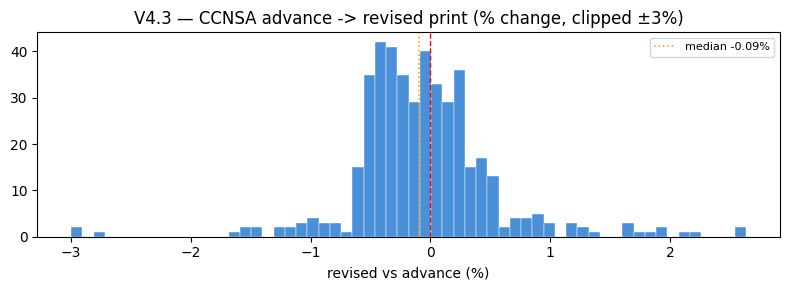

In [32]:
# V4.3 — advance -> revised gap, calibrated on national CCNSA (archives both prints)
# WHY: V3.7 showed state vintages MIX print types across eras — pre-2020 REVISED, post-2020 ADVANCE.
# States rarely archive both; national CCNSA does -> bounds the era-mixing inconsistency.
d = fred_get({"series_id": "CCNSA", "realtime_start": "2018-01-01", "realtime_end": "9999-12-31",
              "observation_start": "2018-01-01", "output_type": 2, "limit": 100000})
t = pd.DataFrame(d["observations"])
vcols = [c for c in t.columns if c.startswith("CCNSA")]
vals = t[vcols].replace(".", np.nan).astype(float)

def advance_and_rev1(row):
    v = row.dropna().values
    if len(v) == 0:
        return pd.Series({"advance": np.nan, "rev1": np.nan})
    uniq = v[np.insert(v[:-1] != v[1:], 0, True)]
    return pd.Series({"advance": uniq[0], "rev1": uniq[1] if len(uniq) > 1 else np.nan})

ar = vals.apply(advance_and_rev1, axis=1).dropna()
ar["rev_pct"] = (ar["rev1"] / ar["advance"] - 1) * 100

print("V4.3 — national advance vs revised print (informational calibration):")
print(f"  weeks with both prints: {len(ar):,}")
print(f"  median change: {ar['rev_pct'].median():+.2f}%")
print(f"  IQR: [{ar['rev_pct'].quantile(.25):+.2f}%, {ar['rev_pct'].quantile(.75):+.2f}%]")
print(f"  max |change|: {ar['rev_pct'].abs().max():.1f}%")

add_check("V4", "V4.3", "Advance vs revised print: how different are they? (national calibration)",
          "PASS",
          metric=f"median {ar['rev_pct'].median():+.2f}%, IQR [{ar['rev_pct'].quantile(.25):+.2f}%, "
                 f"{ar['rev_pct'].quantile(.75):+.2f}%], max |{ar['rev_pct'].abs().max():.1f}%|",
          threshold="informational calibration",
          note="the typical advance->revised change is ~-0.1% (the advance slightly OVERSTATES claims), "
               "IQR +-0.3%, tails ~6% in COVID weeks. VERDICT: the V3.7 era mixing (revised prints "
               "pre-2020 vs advance prints post-2020) is a second-order inconsistency for state "
               "features — acceptable; add an era dummy if precise levels matter.")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ar["rev_pct"].clip(-3, 3), bins=60, edgecolor="white", linewidth=0.3, color="#4a90d9")
ax.axvline(0, color="red", ls="--", lw=1)
ax.axvline(ar["rev_pct"].median(), color="orange", ls=":", lw=1.2,
           label=f"median {ar['rev_pct'].median():+.2f}%")
ax.set(title="V4.3 — CCNSA advance -> revised print (% change, clipped ±3%)",
       xlabel="revised vs advance (%)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
